# 06 — Resultater til thesis (kapittel 7)

Speiler eksakt strukturen i `thesis/results/resultater.tex`.
Hver markdown-overskrift = én seksjon i resultatkapitlet.
Under hver overskrift: tabellene og figurene som skal inn i kapitlet.

**Input:** alle filer i `intermediate/` (produsert av notebook 01–05)
**Output:** figurer lagres i `../figures/notebook/06/`

Total Stargate-effekt beregnes via Roy-dekomponeringen:
$$\Delta E[P] \;\approx\; \Pr(I=1)\cdot\Delta E[P\mid I=1] \;+\; \Delta\Pr(I=1)\cdot\Delta P_{\text{gap}}$$
der **Term 1** = direkte effekt i ISO-timer og **Term 2** = effekt av regimeskift.

## Oppsett — last alle data og modeller

In [5]:
import os, warnings, pickle
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from src.config import (
    TRAIN_YEARS, TEST_YEARS, INTERMEDIATE_DIR, FIG_DIR,
    TARGET, MODEL_FEATURES,
    STARGATE_MW, STARGATE_TOTAL_MW,
    SCALE_COLS, SCALED_NAME_MAP, SEASON_DUMMIES, SEASON_ORDER,
    apply_style, C1, C2, C3, C4, C5, PALETTE
)
from src.evaluation import demand_level

apply_style()

FIG6 = FIG_DIR + "06/"
os.makedirs(FIG6, exist_ok=True)

SEASON_LABELS = SEASON_ORDER  # {"Winter":"Vinter", ...}
DEMAND_LEVELS = ["Lav", "Normal", "Høy"]

In [6]:
# Datasett
df     = pd.read_parquet(INTERMEDIATE_DIR + "df_processed.parquet")
df_iso = pd.read_parquet(INTERMEDIATE_DIR + "df_iso.parquet")

# Scenarier (notebook 05)
with open(INTERMEDIATE_DIR + "scenarios.pkl", "rb") as f:
    scen_data = pickle.load(f)
scenarios         = scen_data["scenarios"]
MODEL_DP          = scen_data["MODEL_DP"]
iso_share_results = scen_data["iso_share_results"]
p90_threshold     = scen_data["p90_threshold"]

iso_share_df = pd.DataFrame(iso_share_results).set_index("Scenario")

# Modeller
with open(INTERMEDIATE_DIR + "models_ols.pkl",      "rb") as f: ols_model = pickle.load(f)["estimator"]
with open(INTERMEDIATE_DIR + "models_tsls.pkl",     "rb") as f: tsls_estimator = pickle.load(f)["estimator"]
with open(INTERMEDIATE_DIR + "models_quantreg.pkl", "rb") as f: quantreg_estimators = pickle.load(f)["estimators"]
with open(INTERMEDIATE_DIR + "models_msdr.pkl",     "rb") as f: msdr_data = pickle.load(f)
with open(INTERMEDIATE_DIR + "models_ols_seasonal.pkl", "rb") as f: seasonal_models = pickle.load(f)["models"]

# Sørg for at scenario-tabellene har alle pris-effektmodellene, også når
# scenarios.pkl kommer fra en eldre notebook 05 uten lineære modeller.
def _add_linear_scenario_effect(label, col, estimator):
    if estimator is None:
        return
    beta = estimator.params["cons_NO4"]
    for delta, res in scenarios.items():
        if col not in res.columns:
            res[col] = beta * delta
        scen_col = f"P_scen_{col}"
        if scen_col not in res.columns:
            base_price = df_iso[TARGET].reindex(res.index).values
            res[scen_col] = base_price + res[col].values

_add_linear_scenario_effect("2SLS (HAC)",   "dP_TSLS", tsls_estimator)
_add_linear_scenario_effect("OLS (HAC)",    "dP_OLS",  ols_model)
_add_linear_scenario_effect("QuantReg Q50", "dP_Q50",  quantreg_estimators.get(0.5))
_add_linear_scenario_effect("QuantReg Q90", "dP_Q90",  quantreg_estimators.get(0.9))

# Én samlet modellrekkefølge brukt i alle tabeller/figurer etter 7.3.
_model_order = [
    ("2SLS (HAC)",   "dP_TSLS"),
    ("OLS (HAC)",    "dP_OLS"),
    ("QuantReg Q50", "dP_Q50"),
    ("QuantReg Q90", "dP_Q90"),
    ("OLS (sesong)", "dP_OLS_seasonal"),
    ("XGBoost",      "dP_XGB"),
    ("MS-DR",        "dP_MSDR"),
]
MODEL_DP = {
    name: col
    for name, col in _model_order
    if all(col in res.columns for res in scenarios.values())
}

# CV-koeffisienter
with open(INTERMEDIATE_DIR + "cv_folds.pkl", "rb") as f:
    cv_coef_df = pickle.load(f)["cv_coef_df"]

# Etterspørselsterskler basert på treningsperioden (1/3, 2/3 percentiles)
train_cons = df_iso.loc[df_iso.index.year.isin(TRAIN_YEARS), "cons_NO4"]
t1, t2 = train_cons.quantile([1/3, 2/3])

print(f"df_iso: {len(df_iso):,} ISO-timer | df: {len(df):,} totalt")
print(f"Modeller: {list(MODEL_DP.keys())}")
print(f"P90-terskel pris: {p90_threshold:.0f} NOK/MWh")


df_iso: 34,916 ISO-timer | df: 53,394 totalt
Modeller: ['2SLS (HAC)', 'OLS (HAC)', 'QuantReg Q50', 'QuantReg Q90', 'OLS (sesong)', 'XGBoost', 'MS-DR']
P90-terskel pris: 544 NOK/MWh


---
# 7.1 Kort oversikt over datasett og regimer

In [7]:
# Tabell: datasett-omfang
rows = []
for label, idx in [("Hele perioden 2020–2026", df.index),
                   ("Treningsperiode 2020–2023", df.index[df.index.year.isin(TRAIN_YEARS)]),
                   ("Testperiode 2024–2026",   df.index[df.index.year.isin(TEST_YEARS)])]:
    n_total = len(idx)
    n_iso   = df.loc[idx, "regime_group"].eq("ISO").sum()
    rows.append({
        "Periode":       label,
        "Timer totalt":  f"{n_total:,}",
        "ISO-timer":     f"{n_iso:,}",
        "ISO-andel (%)": f"{100*n_iso/n_total:.1f}",
    })

print("Tabell 7.1: Datasett-omfang og ISO-andel")
display(pd.DataFrame(rows).set_index("Periode"))

Tabell 7.1: Datasett-omfang og ISO-andel


,Timer totalt,ISO-timer,ISO-andel (%)
Periode,,,
Hele perioden 2020–2026,"53,394","34,916",65.4
Treningsperiode 2020–2023,"35,060","25,072",71.5
Testperiode 2024–2026,"18,334","9,844",53.7


In [8]:
# Tabell: pris og forbruk — deskriptiv statistikk i ISO-timer
summary_cols = {
    "price_NO4":     "Pris (NOK/MWh)",
    "cons_NO4":      "Forbruk (MW)",
    "prod_wind_NO4": "Vindproduksjon (MW)",
    "fill_rate":     "Magasinfylling",
}
desc = df_iso[list(summary_cols)].describe(percentiles=[0.1, 0.5, 0.9]).T
desc = desc[["mean", "std", "10%", "50%", "90%"]].round(1)
desc.index = [summary_cols[c] for c in desc.index]
desc.columns = ["Snitt", "Std", "P10", "Median", "P90"]

print("Tabell 7.2: Deskriptiv statistikk i ISO-timer (hele perioden)")
display(desc)

Tabell 7.2: Deskriptiv statistikk i ISO-timer (hele perioden)


,Snitt,Std,P10,Median,P90
Pris (NOK/MWh),270.7,292.6,27.3,207.2,543.6
Forbruk (MW),2276.8,410.8,1745.0,2281.0,2819.0
Vindproduksjon (MW),301.5,210.3,61.0,256.0,600.0
Magasinfylling,0.7,0.2,0.4,0.7,0.9


---
# 7.2 Gjennomsnittlig priseffekt av Stargate (delspørsmål 1.1)

Gjennomsnittlig $\Delta P$ over alle ISO-timer i testperioden ved +230 MW Stargate-last.

In [9]:
# Tabell: gjennomsnittlig ΔP per modell, +230 MW
# Lineære modeller (OLS, 2SLS, Q50, Q90): ΔP = β̂ × Δ MW (eksakt)
# Ikke-lineære (XGBoost, MS-DR, OLS sesong): snitt av per-time simulert ΔP fra scenarios

linear_specs = [
    ("2SLS (HAC)",   tsls_estimator,                 "std_errors"),
    ("OLS (HAC)",    ols_model,                      "bse"),
    ("QuantReg Q50", quantreg_estimators.get(0.5),   "bse"),
    ("QuantReg Q90", quantreg_estimators.get(0.9),   "bse"),
]

rows = []
# Lineære modeller — analytisk β × ΔMW + KI
for name, est, attr_se in linear_specs:
    if est is None:
        continue
    b  = est.params["cons_NO4"]
    se = getattr(est, attr_se)["cons_NO4"]
    rows.append({
        "Modell":     name,
        "β̂ (cons_NO4)": round(b, 4),
        "ΔP +230 MW": round(b * STARGATE_MW, 1),
        "95% KI +230": f"[{(b-1.96*se)*STARGATE_MW:+.1f}, {(b+1.96*se)*STARGATE_MW:+.1f}]",
    })

# Ikke-lineære: snitt av simulert ΔP per time
for name in ["OLS (sesong)", "XGBoost", "MS-DR"]:
    col = MODEL_DP[name]
    rows.append({
        "Modell":      name,
        "β̂ (cons_NO4)": "—",
        "ΔP +230 MW":  round(scenarios[STARGATE_MW][col].mean(), 1),
        "95% KI +230": "—",
    })

print("Tabell 7.3: Gjennomsnittlig ΔP per modell (+230 MW)")
display(pd.DataFrame(rows).set_index("Modell"))

print("\nMerk: 2SLS er hovedmodellen og rapporteres med 95 % HAC-KI. "
      "Ikke-lineære modeller (XGBoost, MS-DR, OLS sesong) er snitt av per-time-simulering "
      "siden ΔP ikke er konstant over observasjoner.")


Tabell 7.3: Gjennomsnittlig ΔP per modell (+230 MW)


,β̂ (cons_NO4),ΔP +230 MW,95% KI +230
Modell,,,
2SLS (HAC),0.6163,141.700000,"[+104.7, +178.8]"
OLS (HAC),0.3034,69.800000,"[+53.5, +86.1]"
QuantReg Q50,0.1112,25.600000,"[+23.4, +27.8]"
QuantReg Q90,0.2214,50.900000,"[+46.9, +55.0]"
OLS (sesong),—,58.000000,—
XGBoost,—,64.400002,—
MS-DR,—,62.600000,—



Merk: 2SLS er hovedmodellen og rapporteres med 95 % HAC-KI. Ikke-lineære modeller (XGBoost, MS-DR, OLS sesong) er snitt av per-time-simulering siden ΔP ikke er konstant over observasjoner.


,Modell,Sentralverdi,Lav,Høy,Intervalltype
0,2SLS (HAC),141.7,104.7,178.8,95 % KI
1,OLS (HAC),69.8,53.5,86.1,95 % KI
2,QuantReg Q50,25.6,23.4,27.8,95 % KI
3,QuantReg Q90,50.9,46.9,55.0,95 % KI
4,OLS (sesong),58.0,-37.5,158.7,Sesongspenn
5,XGBoost,64.4,3.5,121.1,Sesongspenn
6,MS-DR,62.6,60.6,64.7,95 % KI


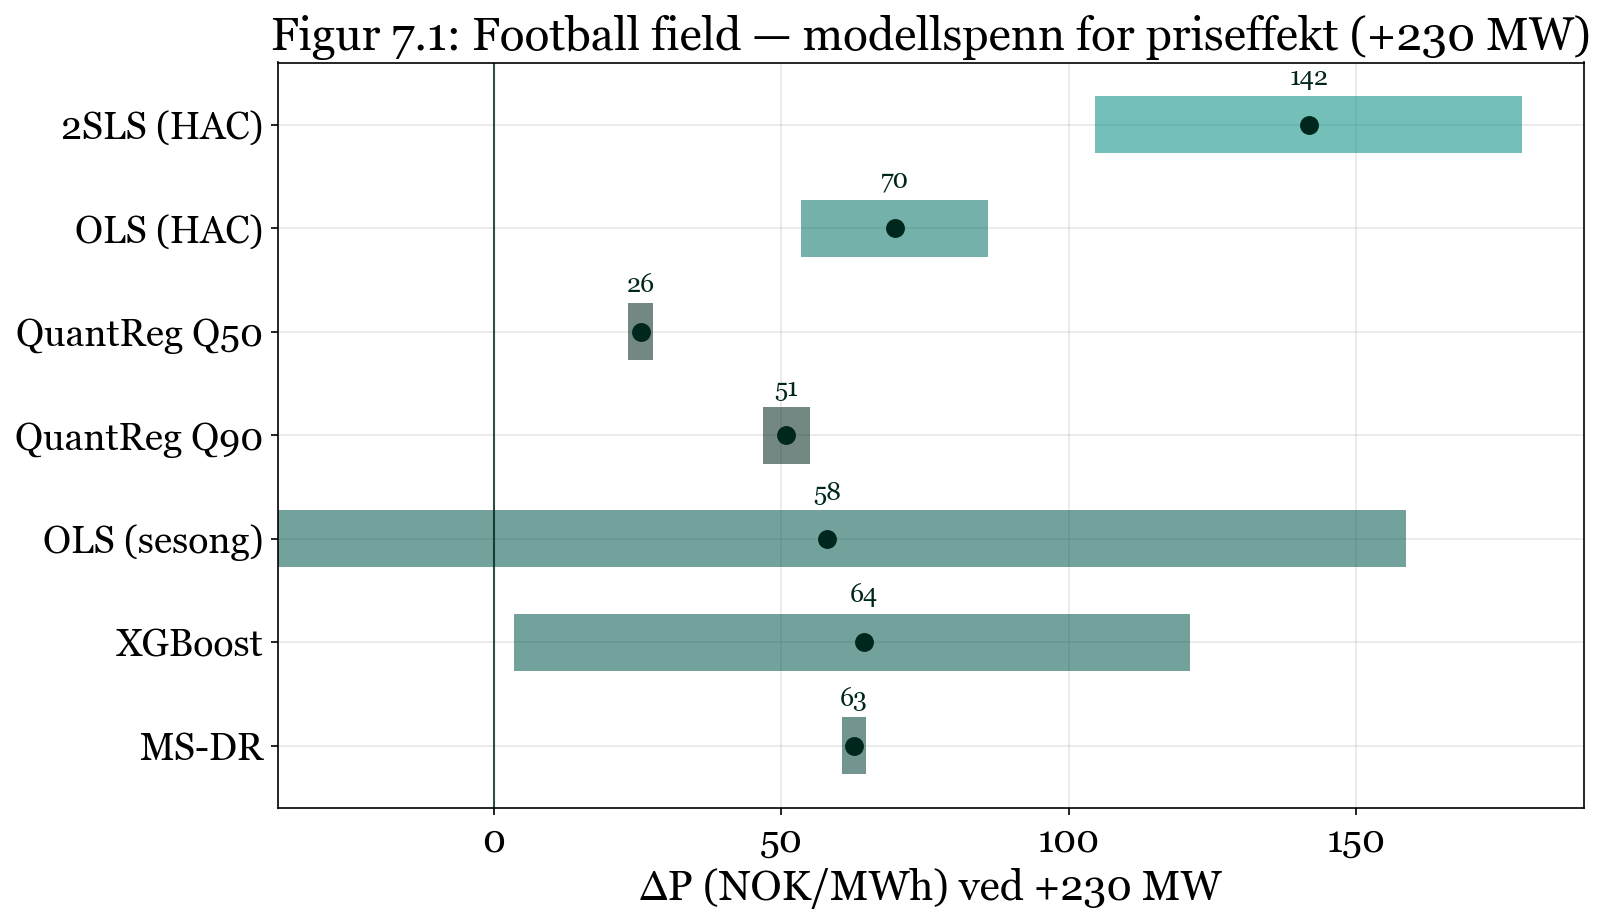

Lagret: ../figures/notebook/06/72_football_field_dP.pdf


In [10]:
# Figur 7.1: Football field — modellspenn for gjennomsnittlig priseffekt
# Én rad per modell i tabell 7.3. Søyle = intervall, punkt = sentralverdi.

res230 = scenarios[STARGATE_MW]

def _linear_dp_interval(est, se_attr, delta=STARGATE_MW):
    b = est.params["cons_NO4"]
    se = getattr(est, se_attr)["cons_NO4"]
    return b * delta, (b - 1.96 * se) * delta, (b + 1.96 * se) * delta

def _season_span(col):
    means = [
        res230.loc[res230["season"] == season, col].mean()
        for season in SEASON_ORDER
        if season in set(res230["season"].dropna())
    ]
    means = [m for m in means if pd.notna(m)]
    central = res230[col].mean()
    return central, min(means), max(means)

football_rows = []

# Lineære modeller: punktestimat og 95 % konfidensintervall
football_rows.append(("2SLS (HAC)", *_linear_dp_interval(tsls_estimator, "std_errors"), C1, "95 % KI"))
football_rows.append(("OLS (HAC)", *_linear_dp_interval(ols_model, "bse"), C2, "95 % KI"))

if 0.5 in quantreg_estimators:
    football_rows.append(("QuantReg Q50", *_linear_dp_interval(quantreg_estimators[0.5], "bse"), C5, "95 % KI"))
if 0.9 in quantreg_estimators:
    football_rows.append(("QuantReg Q90", *_linear_dp_interval(quantreg_estimators[0.9], "bse"), C5, "95 % KI"))

# Ikke-lineære modeller: gjennomsnitt over timer og spenn mellom sesonger
football_rows.append(("OLS (sesong)", *_season_span(MODEL_DP["OLS (sesong)"]), C3, "Sesongspenn"))
football_rows.append(("XGBoost", *_season_span(MODEL_DP["XGBoost"]), C3, "Sesongspenn"))

# MS-DR: vektet effekt og vektet 95 % KI fra regimekoeffisientene
msdr_res = msdr_data["estimator"]
b0, b1 = msdr_res.params["x1[0]"], msdr_res.params["x1[1]"]
ci = msdr_res.conf_int(alpha=0.05)
ci0, ci1 = ci.loc["x1[0]"].values, ci.loc["x1[1]"].values
pi0, pi1 = msdr_data["ergodic_probs"]
msdr_central = res230[MODEL_DP["MS-DR"]].mean()
msdr_lo = (pi0 * ci0[0] + pi1 * ci1[0]) * STARGATE_MW
msdr_hi = (pi0 * ci0[1] + pi1 * ci1[1]) * STARGATE_MW
football_rows.append(("MS-DR", msdr_central, msdr_lo, msdr_hi, C4, "95 % KI"))

football_df = pd.DataFrame(
    football_rows,
    columns=["Modell", "Sentralverdi", "Lav", "Høy", "Farge", "Intervalltype"]
).dropna()

# Samme rekkefølge som tabell 7.3
order = ["2SLS (HAC)", "OLS (HAC)", "QuantReg Q50", "QuantReg Q90", "OLS (sesong)", "XGBoost", "MS-DR"]
football_df["Modell"] = pd.Categorical(football_df["Modell"], categories=order, ordered=True)
football_df = football_df.sort_values("Modell")

fig, ax = plt.subplots(figsize=(11, 6.5))
y = np.arange(len(football_df))

for i, row in enumerate(football_df.itertuples(index=False)):
    ax.barh(
        i, row.Høy - row.Lav, left=row.Lav, height=0.55,
        color=row.Farge, alpha=0.55, zorder=2
    )
    ax.scatter(row.Sentralverdi, i, color=C5, s=65, zorder=3)
    ax.text(
        row.Sentralverdi, i - 0.33, f"{row.Sentralverdi:.0f}",
        ha="center", va="bottom", fontsize=12, color=C5
    )

ax.axvline(0, color=C5, lw=1.0, alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels(football_df["Modell"])
ax.set_xlabel(f"ΔP (NOK/MWh) ved +{STARGATE_MW} MW")
ax.set_title(f"Figur 7.1: Football field — modellspenn for priseffekt (+{STARGATE_MW} MW)")
ax.invert_yaxis()

# Forklar intervalltypene uten å legge inn tekst i selve figuren.
display(football_df[["Modell", "Sentralverdi", "Lav", "Høy", "Intervalltype"]].round(1))

plt.tight_layout()
plt.savefig(FIG6 + "72_football_field_dP.pdf", bbox_inches="tight")
plt.show()

print(f"Lagret: {FIG6}72_football_field_dP.pdf")


---
# 7.3 Heterogenitet: sesong og etterspørsel (delspørsmål 1.2)

In [11]:
# Tabell: ΔP per sesong, alle modeller, +230 MW
res = scenarios[STARGATE_MW]
rows = []
for name, col in MODEL_DP.items():
    row = {"Modell": name, "Total": round(res[col].mean(), 1)}
    for s_en, s_no in SEASON_ORDER.items():
        row[s_no] = round(res.loc[res["season"] == s_en, col].mean(), 1)
    rows.append(row)
print("\nTabell 7.4: ΔP (NOK/MWh) per sesong — +230 MW")
display(pd.DataFrame(rows).set_index("Modell").style.format("{:.1f}"))



Tabell 7.4: ΔP (NOK/MWh) per sesong — +230 MW


,Total,Vinter,Vår,Sommer,Høst
Modell,,,,,
2SLS (HAC),141.7,141.7,141.7,141.7,141.7
OLS (HAC),69.8,69.8,69.8,69.8,69.8
QuantReg Q50,25.6,25.6,25.6,25.6,25.6
QuantReg Q90,50.9,50.9,50.9,50.9,50.9
OLS (sesong),58.0,158.7,61.5,-37.5,39.0
XGBoost,64.4,121.1,56.2,3.5,71.5
MS-DR,62.6,62.6,62.6,62.6,62.6


In [12]:
# Tabell: ΔP per etterspørselsnivå, alle modeller, +230 MW
res = scenarios[STARGATE_MW]
rows = []
for lvl in DEMAND_LEVELS:
    mask = res["demand_level"] == lvl
    row = {"Etterspørsel": lvl}
    for name, col in MODEL_DP.items():
        row[name] = round(res.loc[mask, col].mean(), 1)
    rows.append(row)
print("\nTabell 7.5: ΔP (NOK/MWh) per etterspørselsnivå — +230 MW")
display(pd.DataFrame(rows).set_index("Etterspørsel").style.format("{:.1f}"))



Tabell 7.5: ΔP (NOK/MWh) per etterspørselsnivå — +230 MW


,2SLS (HAC),OLS (HAC),QuantReg Q50,QuantReg Q90,OLS (sesong),XGBoost,MS-DR
Etterspørsel,,,,,,,
Lav,141.7,69.8,25.6,50.9,-11.1,4.1,62.6
Normal,141.7,69.8,25.6,50.9,52.3,51.6,62.6
Høy,141.7,69.8,25.6,50.9,118.3,124.0,62.6


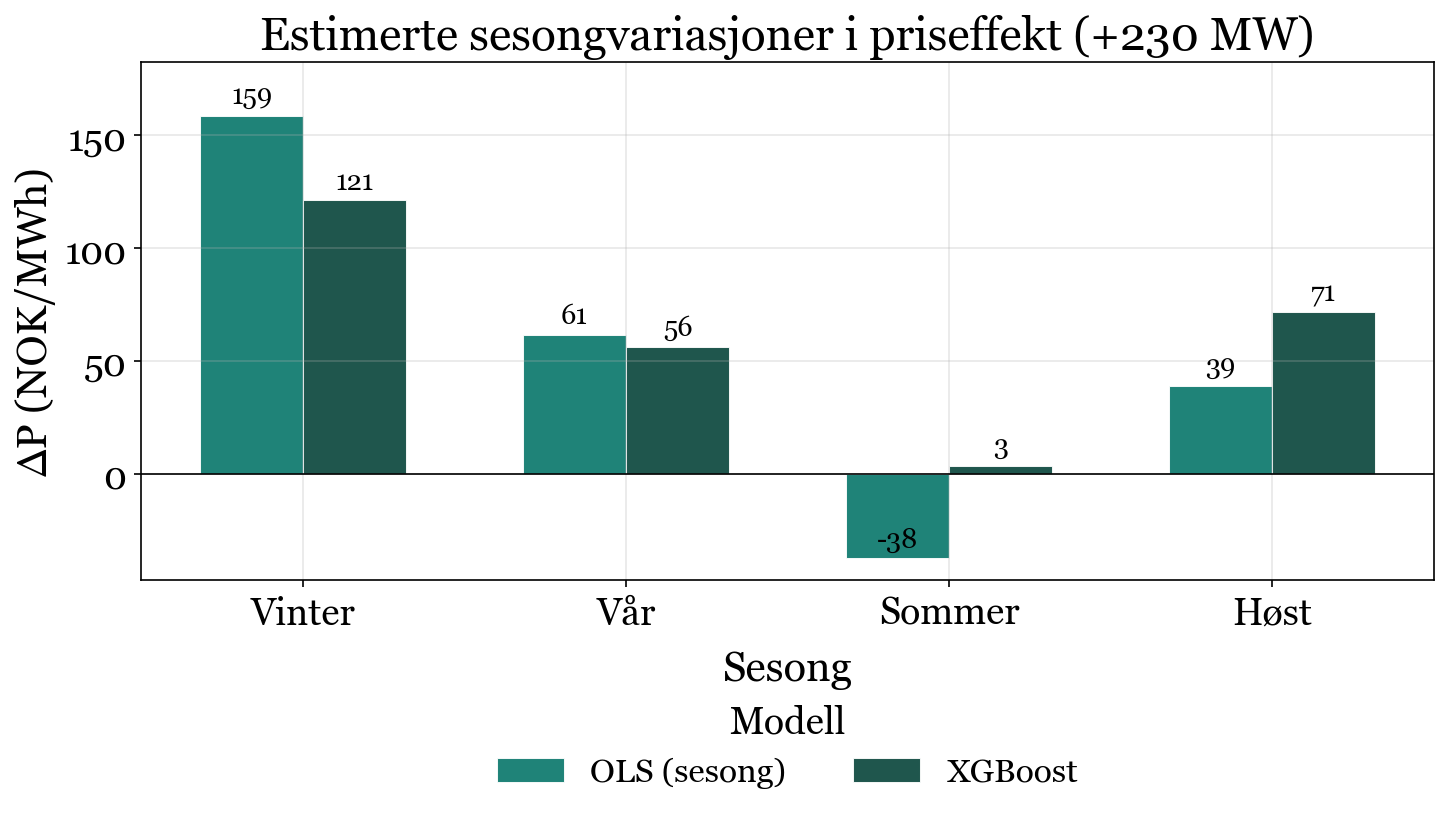

In [13]:
# Figur: ΔP per sesong, modeller som varierer over sesong (+230 MW)
res = scenarios[STARGATE_MW]
models_to_plot = {
    "OLS (sesong)": MODEL_DP["OLS (sesong)"],
    "XGBoost": MODEL_DP["XGBoost"],
}
seasons_no = list(SEASON_ORDER.values())
x = np.arange(len(seasons_no))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 6))
all_vals = []
for i, (name, col) in enumerate(models_to_plot.items()):
    vals = [res.loc[res["season"] == s_en, col].mean() for s_en in SEASON_ORDER]
    all_vals.extend([v for v in vals if pd.notna(v)])
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=name,
                  color=[C2, C4][i], alpha=0.88,
                  edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        if pd.notna(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(all_vals) * 0.015,
                    f"{v:.0f}", ha="center", va="bottom", fontsize=13)

ax.set_xticks(x)
ax.set_xticklabels(seasons_no)
ax.set_xlabel("Sesong", labelpad=8)
ax.set_ylabel("ΔP (NOK/MWh)")
ax.set_title("Estimerte sesongvariasjoner i priseffekt (+230 MW)")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylim(top=max(all_vals) * 1.15)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels,
          title="Modell", ncol=2, frameon=False,
          bbox_to_anchor=(0.5, -0.18), loc="upper center", fontsize=16)

plt.tight_layout()
plt.savefig(FIG6 + "72_dp_per_sesong.pdf", bbox_inches="tight")
plt.show()


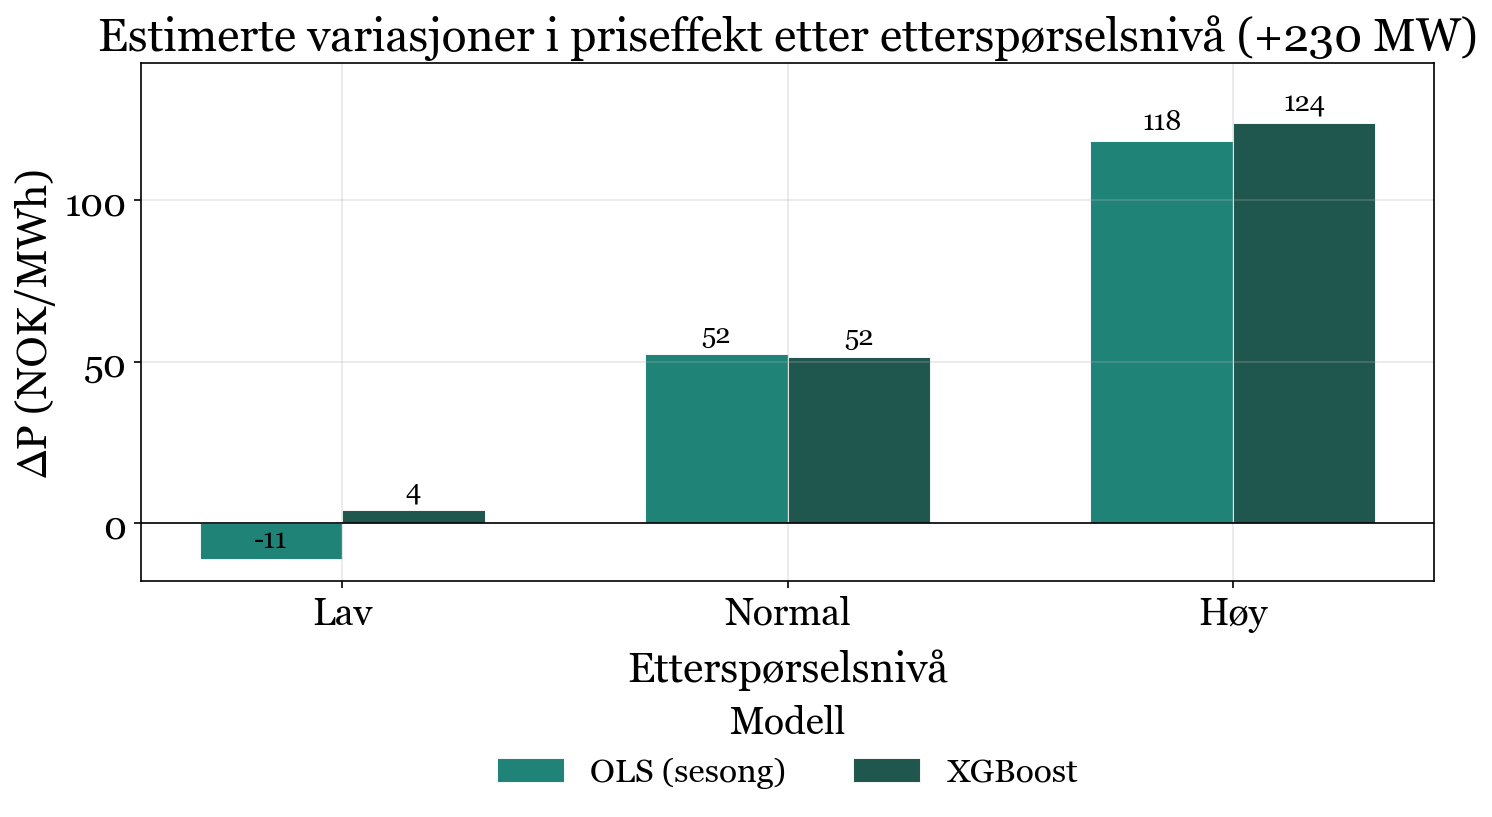

In [14]:
# Figur: ΔP per etterspørselsnivå, modeller som varierer over nivå (+230 MW)
res = scenarios[STARGATE_MW]
models_to_plot = {
    "OLS (sesong)": MODEL_DP["OLS (sesong)"],
    "XGBoost": MODEL_DP["XGBoost"],
}
x = np.arange(len(DEMAND_LEVELS))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 6))
all_vals = []
for i, (name, col) in enumerate(models_to_plot.items()):
    vals = [res.loc[res["demand_level"] == lvl, col].mean() for lvl in DEMAND_LEVELS]
    all_vals.extend([v for v in vals if pd.notna(v)])
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=name,
                  color=[C2, C4][i], alpha=0.88,
                  edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        if pd.notna(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(all_vals) * 0.015,
                    f"{v:.0f}", ha="center", va="bottom", fontsize=13)

ax.set_xticks(x)
ax.set_xticklabels(DEMAND_LEVELS)
ax.set_xlabel("Etterspørselsnivå", labelpad=8)
ax.set_ylabel("ΔP (NOK/MWh)")
ax.set_title("Estimerte variasjoner i priseffekt etter etterspørselsnivå (+230 MW)")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylim(top=max(all_vals) * 1.15)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels,
          title="Modell", ncol=2, frameon=False,
          bbox_to_anchor=(0.5, -0.18), loc="upper center", fontsize=16)

plt.tight_layout()
plt.savefig(FIG6 + "73_dp_per_etterspørsel.pdf", bbox_inches="tight")
plt.show()


---
# 7.4 Endring i ISO-sannsynlighet/andel (delspørsmål 1.2)

Logistisk regresjon predikerer sannsynligheten for ISO-regime som funksjon av forbruk, magasinfylling og sesong. Hovedscenarioet beregnes ved å øke `cons_NO4` med 230 MW i hele datasettet. +520 MW behandles samlet i robusthets- og skaleringsseksjonen.


In [15]:
# Tabell: ISO-andel total + per sesong (allerede beregnet i notebook 05)
print("Tabell 7.6: Predikert ISO-andel (%) i hovedscenarioet")
display(iso_share_df.loc[["Baseline", "+230 MW"]].style.format("{:.1f}"))

print("\nEndring i ISO-andel relativt til baseline (prosentpoeng):")
delta_iso = iso_share_df.subtract(iso_share_df.loc["Baseline"], axis=1)
display(delta_iso.drop("Baseline").style.format("{:+.1f}"))


Tabell 7.6: Predikert ISO-andel (%) i hovedscenarioet


,Total,Vinter,Vår,Sommer,Høst
Scenario,,,,,
Baseline,72.5,76.0,67.6,75.5,70.8
+230 MW,76.0,79.1,71.4,78.7,74.7



Endring i ISO-andel relativt til baseline (prosentpoeng):


,Total,Vinter,Vår,Sommer,Høst
Scenario,,,,,
+230 MW,+3.5,+3.1,+3.8,+3.2,+3.9
+520 MW,+7.5,+6.7,+8.3,+6.9,+8.2


In [16]:
# Beregn ISO-sannsynlighet per etterspørselsnivå — trenger å reestimere logit
df["is_iso"] = (df["regime_group"] == "ISO").astype(int)
scaler = StandardScaler()
scaler.fit(df.loc[df.index.year.isin(TRAIN_YEARS), SCALE_COLS])
scaled = scaler.transform(df[SCALE_COLS])
for i, col in enumerate(SCALE_COLS):
    df[SCALED_NAME_MAP[col]] = scaled[:, i]
for s in SEASON_DUMMIES:
    df[s] = (df["season"] == s).astype(int)

LOGIT_FEATURES = ["cons_c", "fill_c"] + SEASON_DUMMIES
df_train = df[df.index.year.isin(TRAIN_YEARS)]
logit_model = LogisticRegression(max_iter=1000, random_state=42)
logit_model.fit(df_train[LOGIT_FEATURES], df_train["is_iso"])

df["demand_level_all"] = df["cons_NO4"].map(lambda c: demand_level(c, t1, t2))

iso_demand_rows = []
for delta, lbl in [(0, "Baseline"), (STARGATE_MW, "+230 MW"), (STARGATE_TOTAL_MW, "+520 MW")]:
    df_s = df.copy()
    if delta > 0:
        df_s["cons_NO4"] += delta
        if "net_position" in df_s.columns:
            df_s["net_position"] = df_s["prod_total_NO4"] - df_s["cons_NO4"]
        sc = scaler.transform(df_s[SCALE_COLS])
        for i, col in enumerate(SCALE_COLS):
            df_s[SCALED_NAME_MAP[col]] = sc[:, i]
    p_hat = logit_model.predict_proba(df_s[LOGIT_FEATURES])[:, 1]
    row = {"Scenario": lbl}
    for lvl in DEMAND_LEVELS:
        m = df["demand_level_all"] == lvl
        row[lvl] = round(100 * p_hat[m.values].mean(), 1)
    iso_demand_rows.append(row)

iso_demand_df = pd.DataFrame(iso_demand_rows).set_index("Scenario")
print("\nTabell 7.7: Predikert ISO-andel (%) per etterspørselsnivå")
display(iso_demand_df.loc[["Baseline", "+230 MW"]].style.format("{:.1f}"))



Tabell 7.7: Predikert ISO-andel (%) per etterspørselsnivå


,Lav,Normal,Høy
Scenario,,,
Baseline,71.1,69.8,76.4
+230 MW,74.7,73.6,79.6


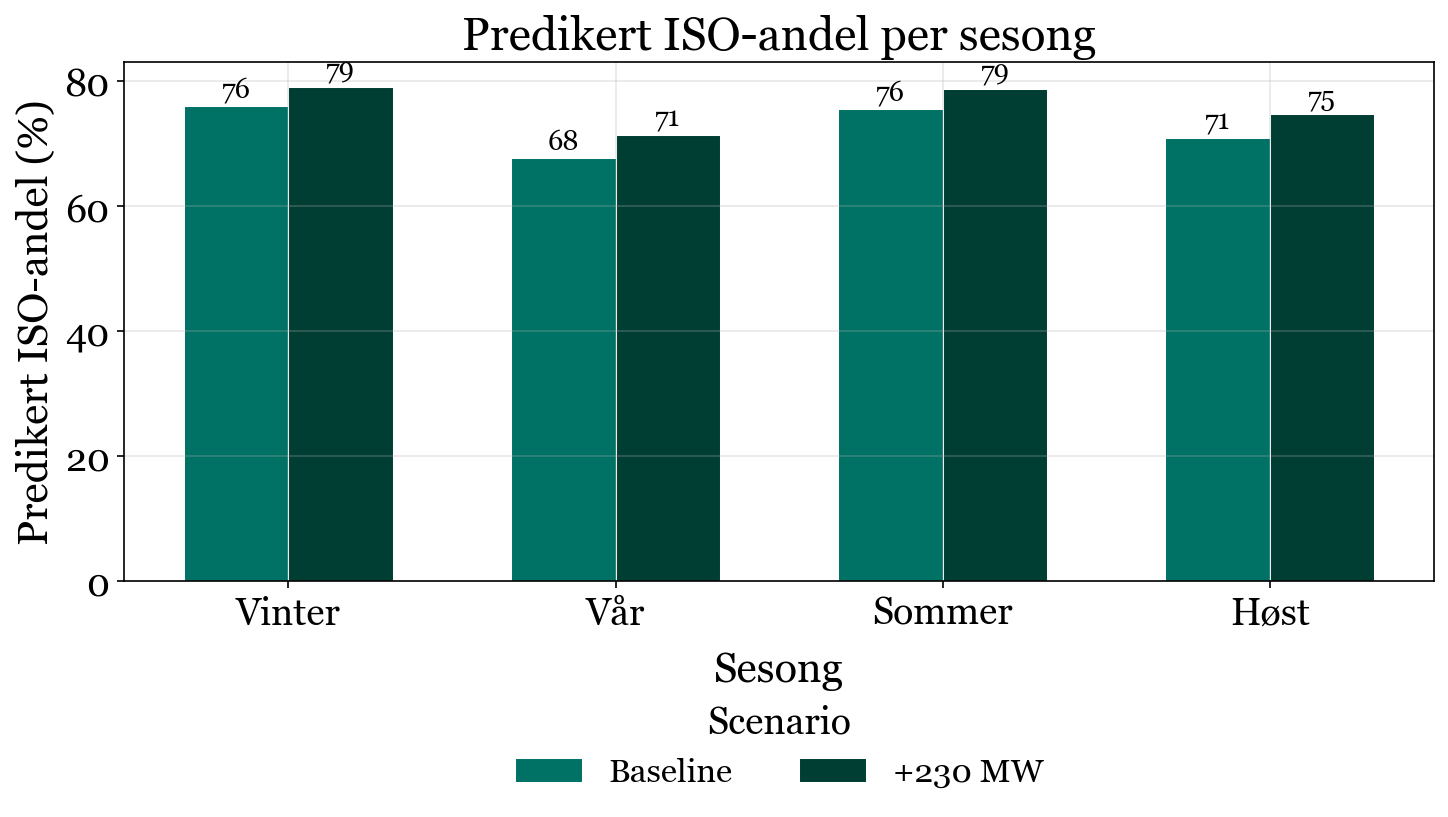

In [17]:
# Figur: ISO-andel per sesong — baseline vs +230 MW
fig, ax = plt.subplots(figsize=(10, 6))
season_cols = [SEASON_ORDER[k] for k in SEASON_ORDER]
x = np.arange(len(season_cols))
width = 0.32

scen_colors = {"Baseline": C2, "+230 MW": C4}
for i, scen in enumerate(["Baseline", "+230 MW"]):
    if scen not in iso_share_df.index:
        continue
    vals = [iso_share_df.loc[scen, s] for s in season_cols]
    bars = ax.bar(x + (i - 0.5)*width, vals, width,
                  color=scen_colors[scen], label=scen,
                  edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{v:.0f}", ha="center", va="bottom", fontsize=13)

ax.set_xticks(x)
ax.set_xticklabels(season_cols)
ax.set_xlabel("Sesong", labelpad=8)
ax.set_ylabel("Predikert ISO-andel (%)")
ax.set_title("Predikert ISO-andel per sesong")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels,
          title="Scenario", ncol=2, frameon=False,
          bbox_to_anchor=(0.5, -0.18), loc="upper center", fontsize=16)

plt.tight_layout()
plt.savefig(FIG6 + "74_iso_andel_sesong.pdf", bbox_inches="tight")
plt.show()


---
# 7.5 Priseffekt i ISO vs pristaker (delspørsmål 2.2)

I ISO-timer setter NO4-prisen seg lokalt og Stargate har direkte effekt.
I pristaker-timer (SYS, FI, NO3, SE1, SE2) er prisen bestemt utenfor NO4 og direkteeffekten av Stargate antas ≈ 0.
MS-DR splitter dessuten ISO-timer i to volatilitetsregimer.

In [18]:
# Historisk prisgap mellom ISO og ikke-ISO — dokumenterer hvor mye dyrere ISO er
p_iso    = df.loc[df["is_iso"] == 1, "price_NO4"]
p_noniso = df.loc[df["is_iso"] == 0, "price_NO4"]
dp_gap_total = p_iso.mean() - p_noniso.mean()

rows = [{
    "Regime":       "ISO",
    "Antall timer": f"{len(p_iso):,}",
    "Snitt pris":   round(p_iso.mean(), 1),
    "Median pris":  round(p_iso.median(), 1),
}, {
    "Regime":       "Pristaker (SYS + nabosoner)",
    "Antall timer": f"{len(p_noniso):,}",
    "Snitt pris":   round(p_noniso.mean(), 1),
    "Median pris":  round(p_noniso.median(), 1),
}]
print("Tabell 7.8: Historisk prisgap ISO vs pristaker")
display(pd.DataFrame(rows).set_index("Regime"))
print(f"\nΔP_gap (ISO − pristaker) = {dp_gap_total:+.1f} NOK/MWh")

Tabell 7.8: Historisk prisgap ISO vs pristaker


,Antall timer,Snitt pris,Median pris
Regime,,,
ISO,"34,916",270.7,207.2
Pristaker (SYS + nabosoner),"18,478",195.3,96.2



ΔP_gap (ISO − pristaker) = +75.4 NOK/MWh


In [19]:
# Tabell: estimert direkteeffekt — ISO vs pristaker (+230 MW)
rows = []
res = scenarios[STARGATE_MW]
for name, col in MODEL_DP.items():
    rows.append({
        "Modell":                name,
        "ΔP|ISO (NOK/MWh)":      round(res[col].mean(), 1),
        "ΔP|pristaker":          0.0,   # antakelse: NO4 er prismottaker, lokal etterspørsel påvirker ikke prisen
    })
print("Tabell 7.9: Direkteeffekt på pris betinget på regime (+230 MW)")
display(pd.DataFrame(rows).set_index("Modell").style.format("{:.1f}"))


Tabell 7.9: Direkteeffekt på pris betinget på regime (+230 MW)


,ΔP|ISO (NOK/MWh),ΔP|pristaker
Modell,,
2SLS (HAC),141.7,0.0
OLS (HAC),69.8,0.0
QuantReg Q50,25.6,0.0
QuantReg Q90,50.9,0.0
OLS (sesong),58.0,0.0
XGBoost,64.4,0.0
MS-DR,62.6,0.0


Tabell 7.10: MS-DR — forbrukskoeffisient per regime (innenfor ISO-timer)


,β̂,95% KI,Steady-state π,ΔP +230 MW
Regime,,,,
Regime 0 (lav volatilitet),0.1470,"[0.1436, 0.1503]",0.5,33.8
Regime 1 (høy volatilitet),0.3975,"[0.3829, 0.4122]",0.5,91.4


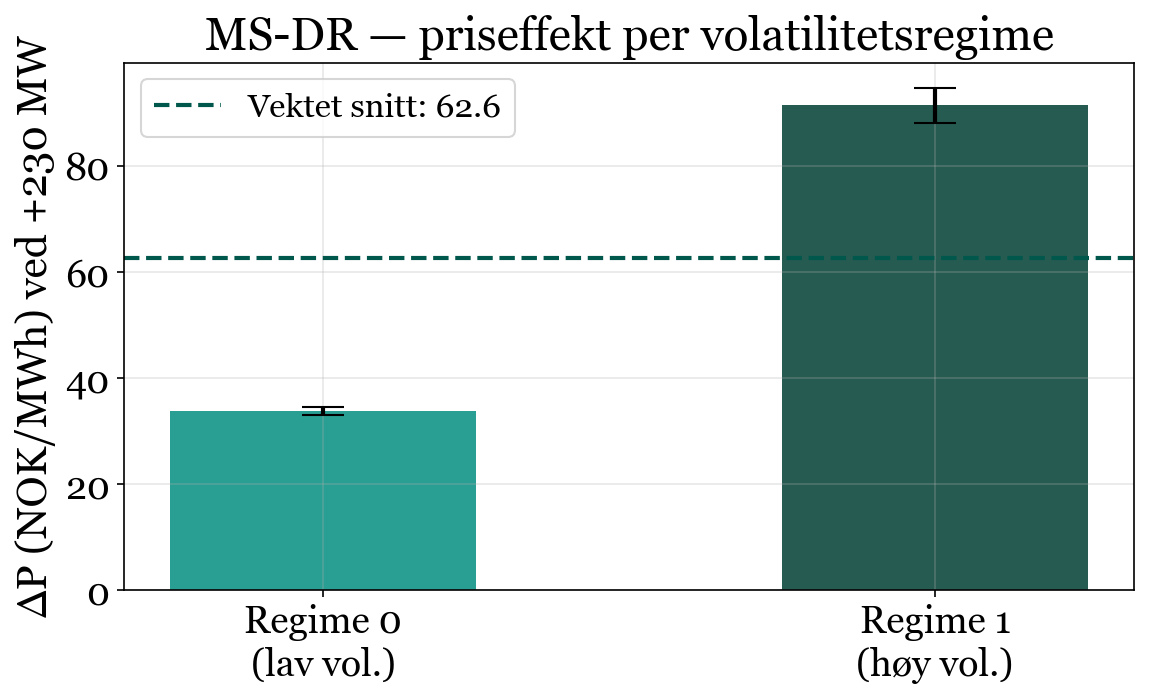

In [20]:
# Figur + tabell: MS-DR — koeffisient per (skjult) volatilitetsregime
msdr_res = msdr_data["estimator"]
b0, b1 = msdr_res.params["x1[0]"], msdr_res.params["x1[1]"]
ci = msdr_res.conf_int(alpha=0.05)
ci0, ci1 = ci.loc["x1[0]"].values, ci.loc["x1[1]"].values
pi0, pi1 = msdr_data["ergodic_probs"]

rows = [
    {"Regime": "Regime 0 (lav volatilitet)", "β̂": round(b0, 4),
     "95% KI": f"[{ci0[0]:.4f}, {ci0[1]:.4f}]",
     "Steady-state π": round(pi0, 3),
     "ΔP +230 MW": round(b0 * STARGATE_MW, 1)},
    {"Regime": "Regime 1 (høy volatilitet)", "β̂": round(b1, 4),
     "95% KI": f"[{ci1[0]:.4f}, {ci1[1]:.4f}]",
     "Steady-state π": round(pi1, 3),
     "ΔP +230 MW": round(b1 * STARGATE_MW, 1)},
]
print("Tabell 7.10: MS-DR — forbrukskoeffisient per regime (innenfor ISO-timer)")
display(pd.DataFrame(rows).set_index("Regime"))

fig, ax = plt.subplots(figsize=(8, 5))
regs   = ["Regime 0\n(lav vol.)", "Regime 1\n(høy vol.)"]
betas  = [b0, b1]; cis = [ci0, ci1]; rcols = [C1, C4]
for i, (b, c, col) in enumerate(zip(betas, cis, rcols)):
    ax.bar(i, b * STARGATE_MW, color=col, alpha=0.85, width=0.5)
    ax.errorbar(i, b * STARGATE_MW,
                yerr=[[(b - c[0]) * STARGATE_MW], [(c[1] - b) * STARGATE_MW]],
                fmt="none", color="black", capsize=10, lw=2)
dP_w = (pi0*b0 + pi1*b1) * STARGATE_MW
ax.axhline(dP_w, color=C3, ls="--", lw=2, label=f"Vektet snitt: {dP_w:.1f}")
ax.set_xticks([0, 1]); ax.set_xticklabels(regs)
ax.set_ylabel("ΔP (NOK/MWh) ved +230 MW")
ax.set_title("MS-DR — priseffekt per volatilitetsregime")
ax.legend()
plt.tight_layout()
plt.savefig(FIG6 + "75_msdr_regime.pdf", bbox_inches="tight")
plt.show()

---
# 7.6 Ekstrempriser (delspørsmål 3.1)

Andel timer over P90-terskel (≈90. persentil av faktisk pris i ISO-timer).

In [21]:
print(f"P90-terskel (basert på faktiske ISO-priser): {p90_threshold:.0f} NOK/MWh\n")

rows = []
for name, col in MODEL_DP.items():
    scen_prices = scenarios[STARGATE_MW][f"P_scen_{col}"]
    base_pct = 100 * (df_iso[TARGET] > p90_threshold).sum() / len(df_iso)
    scen_pct = 100 * (scen_prices > p90_threshold).sum() / len(scen_prices)
    rows.append({
        "Modell":               name,
        "Baseline (%)":         round(base_pct, 1),
        "Scenario (%)":         round(scen_pct, 1),
        "Δ (pp)":               round(scen_pct - base_pct, 1),
    })
print("Tabell 7.11: Andel ISO-timer > P90 — +230 MW")
display(pd.DataFrame(rows).set_index("Modell").style.format("{:.1f}"))


P90-terskel (basert på faktiske ISO-priser): 544 NOK/MWh

Tabell 7.11: Andel ISO-timer > P90 — +230 MW


,Baseline (%),Scenario (%),Δ (pp)
Modell,,,
2SLS (HAC),10.0,20.9,10.9
OLS (HAC),10.0,15.4,5.3
QuantReg Q50,10.0,11.7,1.7
QuantReg Q90,10.0,14.0,4.0
OLS (sesong),10.0,17.4,7.4
XGBoost,10.0,15.6,5.6
MS-DR,10.0,14.8,4.8


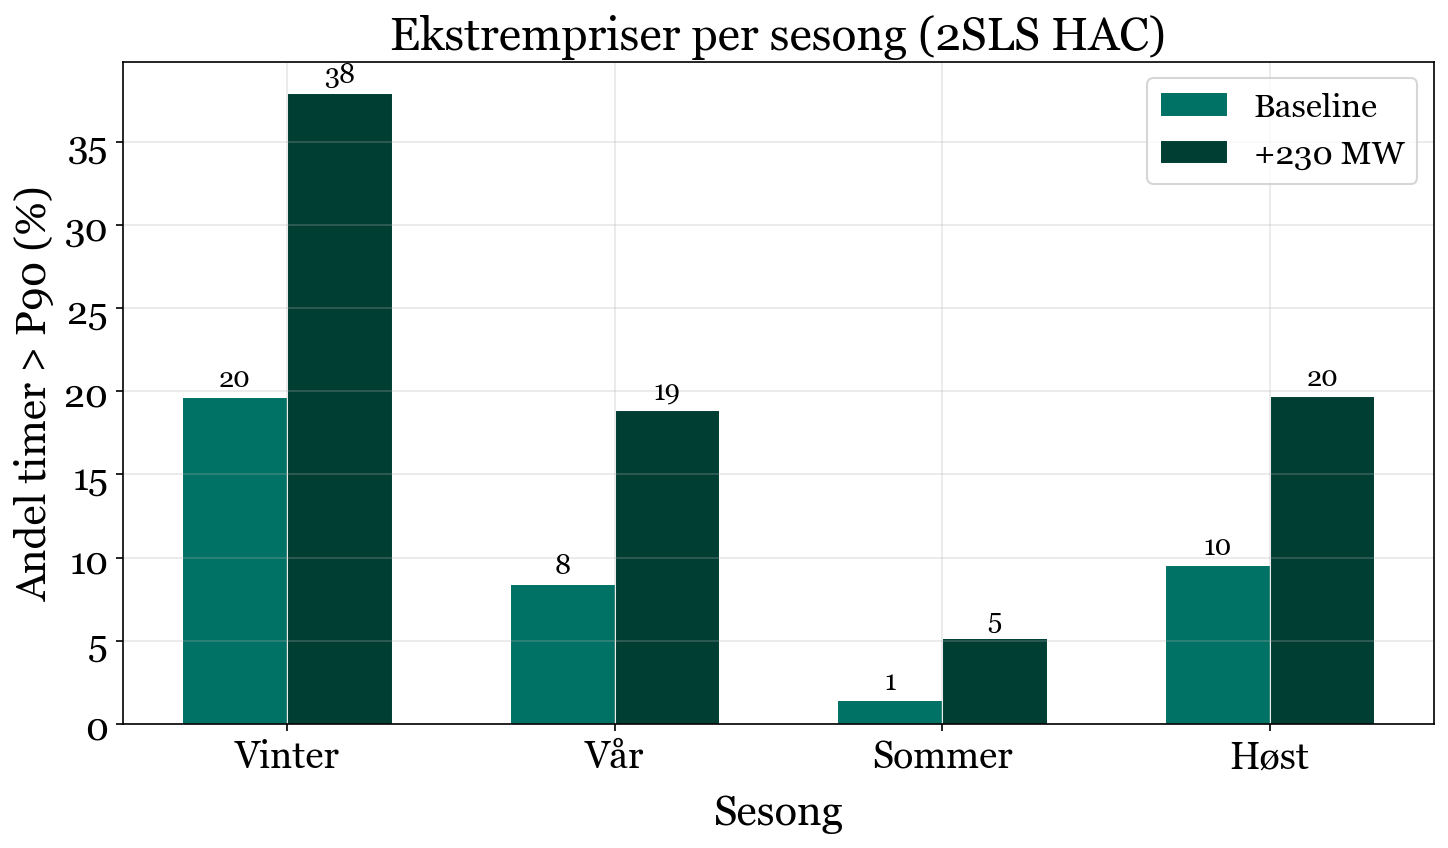

In [22]:
# Figur: ekstrempriser per sesong (2SLS HAC) — baseline vs +230 MW
fig, ax = plt.subplots(figsize=(10, 6))
season_cols = list(SEASON_ORDER.values())
x = np.arange(len(season_cols))
width = 0.32

scenarios_to_plot = [(0, "Baseline", C2), (STARGATE_MW, "+230 MW", C4)]
for i, (delta, lbl, col) in enumerate(scenarios_to_plot):
    vals = []
    for s_en in SEASON_ORDER:
        if delta == 0:
            mask = df_iso["season"] == s_en
            prices = df_iso.loc[mask, TARGET]
        else:
            mask = scenarios[delta]["season"] == s_en
            prices = scenarios[delta].loc[mask, "P_scen_dP_TSLS"]
        vals.append(100 * (prices > p90_threshold).sum() / max(len(prices), 1))
    bars = ax.bar(x + (i - 0.5)*width, vals, width,
                  color=col, label=lbl,
                  edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{v:.0f}", ha="center", va="bottom", fontsize=13)

ax.set_xticks(x)
ax.set_xticklabels(season_cols)
ax.set_xlabel("Sesong", labelpad=8)
ax.set_ylabel("Andel timer > P90 (%)")
ax.set_title("Ekstrempriser per sesong (2SLS HAC)")
ax.legend(fontsize=16)
plt.tight_layout()
plt.savefig(FIG6 + "76_ekstrempriser_sesong.pdf", bbox_inches="tight")
plt.show()


---
# 7.7 Volatilitet (delspørsmål 3.2)

Direkte test for om Stargate øker spredningen i prisfordelingen, ikke bare snittet:
kvantilregresjon Q90 − Q50 og prisstandardavvik baseline vs scenario.

In [23]:
# Tabell: kvantil-koeffisienter — forbruk
rows = []
for q in [0.5, 0.9]:
    if q not in quantreg_estimators: continue
    est = quantreg_estimators[q]
    b, se = est.params["cons_NO4"], est.bse["cons_NO4"]
    rows.append({
        "Kvantil":      f"Q{int(q*100)}",
        "β̂ (cons_NO4)": round(b, 4),
        "SE":           round(se, 4),
        "ΔP +230 MW":   round(b * STARGATE_MW, 1),
    })
print("Tabell 7.12: Kvantilregresjon — forbrukskoeffisient og implisitt ΔP (+230 MW)")
display(pd.DataFrame(rows).set_index("Kvantil"))

if 0.5 in quantreg_estimators and 0.9 in quantreg_estimators:
    b50 = quantreg_estimators[0.5].params["cons_NO4"]
    b90 = quantreg_estimators[0.9].params["cons_NO4"]
    vol = (b90 - b50) * STARGATE_MW
    print(f"\nVolatilitetseffekt (Q90 − Q50) × 230 MW = {vol:+.1f} NOK/MWh")
    print("Positivt: Stargate utvider øvre hale av prisfordelingen mer enn medianen.")


Tabell 7.12: Kvantilregresjon — forbrukskoeffisient og implisitt ΔP (+230 MW)


,β̂ (cons_NO4),SE,ΔP +230 MW
Kvantil,,,
Q50,0.1112,0.0049,25.6
Q90,0.2214,0.0090,50.9



Volatilitetseffekt (Q90 − Q50) × 230 MW = +25.3 NOK/MWh
Positivt: Stargate utvider øvre hale av prisfordelingen mer enn medianen.


In [24]:
# Tabell: prisstandardavvik baseline vs scenario per modell (+230 MW)
rows = []
base_std = df_iso[TARGET].std()
for name, col in MODEL_DP.items():
    scen_std = scenarios[STARGATE_MW][f"P_scen_{col}"].std()
    rows.append({
        "Modell":       name,
        "Std baseline": round(base_std, 1),
        "Std scenario": round(scen_std, 1),
        "Δ std":        round(scen_std - base_std, 1),
    })
print("Tabell 7.13: Standardavvik for pris (NOK/MWh) baseline vs +230 MW")
display(pd.DataFrame(rows).set_index("Modell").style.format("{:.1f}"))


Tabell 7.13: Standardavvik for pris (NOK/MWh) baseline vs +230 MW


,Std baseline,Std scenario,Δ std
Modell,,,
2SLS (HAC),292.6,292.6,0.0
OLS (HAC),292.6,292.6,0.0
QuantReg Q50,292.6,292.6,0.0
QuantReg Q90,292.6,292.6,0.0
OLS (sesong),292.6,321.8,29.2
XGBoost,292.6,330.8,38.2
MS-DR,292.6,292.6,0.0


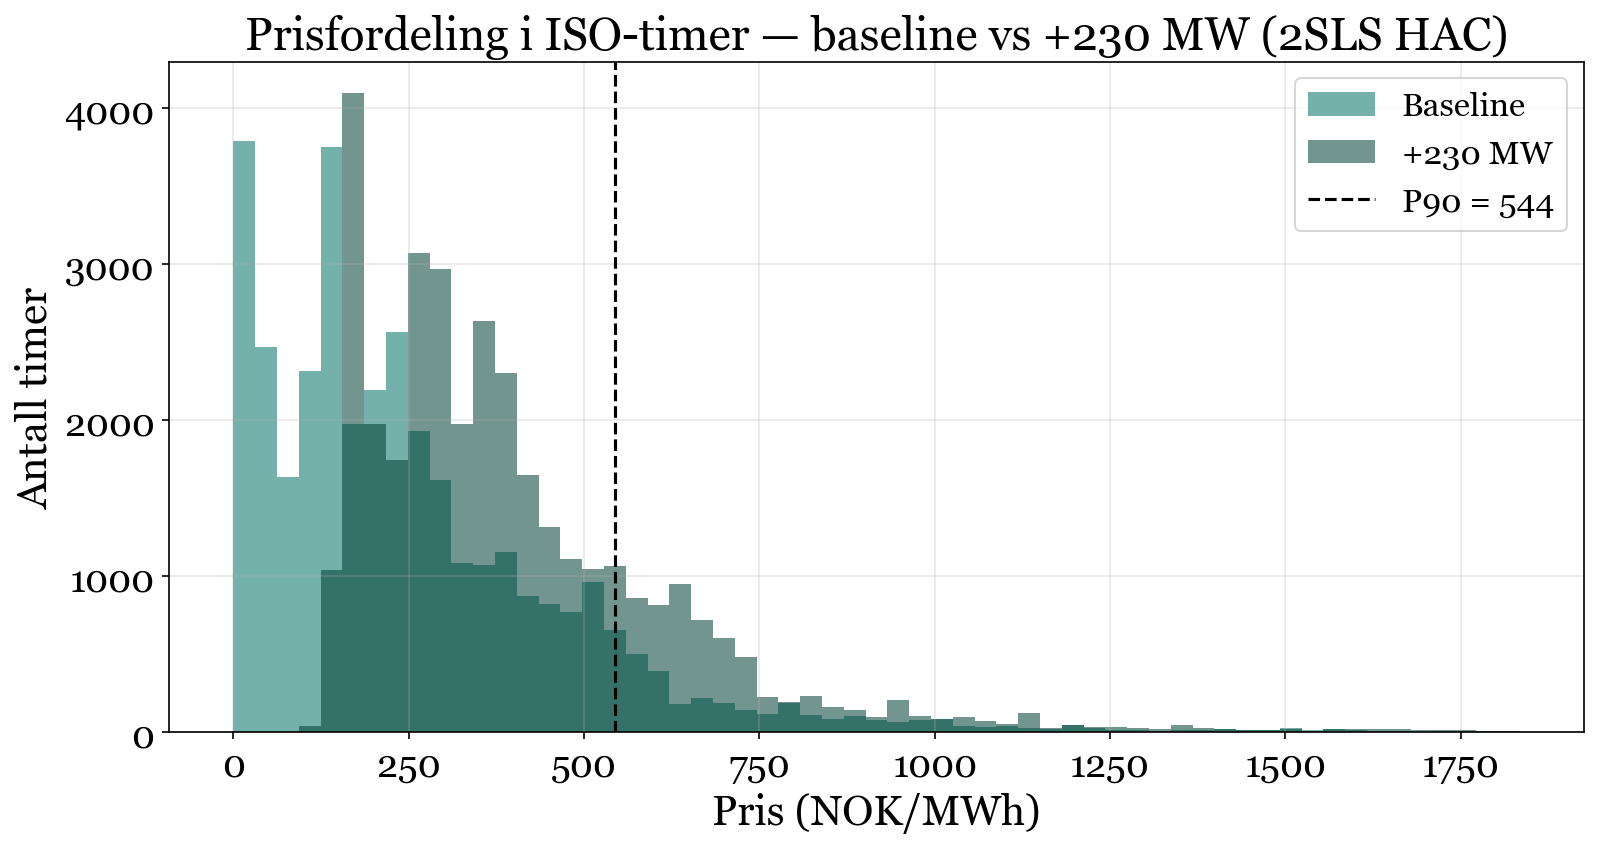

In [25]:
# Figur: prisfordeling baseline vs +230 MW (2SLS HAC)
fig, ax = plt.subplots(figsize=(11, 6))
bins = np.linspace(0, np.percentile(df_iso[TARGET], 99.5), 60)
ax.hist(df_iso[TARGET],                                  bins=bins, alpha=0.55, color=C2, label="Baseline")
ax.hist(scenarios[STARGATE_MW]["P_scen_dP_TSLS"],        bins=bins, alpha=0.55, color=C4, label=f"+{STARGATE_MW} MW")
ax.axvline(p90_threshold, color="black", ls="--", lw=1.5, label=f"P90 = {p90_threshold:.0f}")
ax.set_xlabel("Pris (NOK/MWh)")
ax.set_ylabel("Antall timer")
ax.set_title("Prisfordeling i ISO-timer — baseline vs +230 MW (2SLS HAC)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG6 + "77_prisfordeling.pdf", bbox_inches="tight")
plt.show()


---
# 7.8 Når er effekten størst? (delspørsmål 4.1)

Krysstabell sesong × etterspørselsnivå × magasin. Bruker modeller som kan gi heterogen priseffekt på tvers av observasjoner: OLS (sesong) for sesong × etterspørsel og XGBoost for sesong × magasin.


In [26]:
# Sesong × etterspørsel: ΔP fra OLS (sesong)
res = scenarios[STARGATE_MW]
tab = pd.DataFrame(index=DEMAND_LEVELS, columns=list(SEASON_ORDER.values()), dtype=float)
for s_en, s_no in SEASON_ORDER.items():
    for lvl in DEMAND_LEVELS:
        m = (res["season"] == s_en) & (res["demand_level"] == lvl)
        if m.any():
            tab.loc[lvl, s_no] = res.loc[m, "dP_OLS_seasonal"].mean()
tab = tab.round(1)
print("Tabell 7.14: ΔP (NOK/MWh) per sesong × etterspørselsnivå (OLS sesong, +230 MW)")
display(tab)

Tabell 7.14: ΔP (NOK/MWh) per sesong × etterspørselsnivå (OLS sesong, +230 MW)


,Vinter,Vår,Sommer,Høst
Lav,158.7,61.5,-37.5,39.0
Normal,158.7,61.5,-37.5,39.0
Høy,158.7,61.5,-37.5,39.0


In [27]:
# Sesong × magasin (lavt/høyt) — XGBoost
# Bruker XGBoost fordi 2SLS/OLS HAC gir konstant marginaleffekt innenfor alle ISO-timer.
fill_median = df_iso["fill_rate"].median()
df_iso_aug = df_iso.copy()
df_iso_aug["fill_group"] = np.where(df_iso["fill_rate"] <= fill_median, "Lavt magasin", "Høyt magasin")

# Hent tilsvarende ΔP per time — indeksene matcher mellom df_iso og scenarios
scen = scenarios[STARGATE_MW].copy()
scen["fill_group"] = df_iso_aug.loc[scen.index, "fill_group"].values

tab2 = pd.DataFrame(index=["Lavt magasin", "Høyt magasin"],
                    columns=list(SEASON_ORDER.values()), dtype=float)
for s_en, s_no in SEASON_ORDER.items():
    for fg in ["Lavt magasin", "Høyt magasin"]:
        m = (scen["season"] == s_en) & (scen["fill_group"] == fg)
        if m.any():
            tab2.loc[fg, s_no] = scen.loc[m, "dP_XGB"].mean()
tab2 = tab2.round(1)
print("Tabell 7.15: ΔP (NOK/MWh) per sesong × magasin (XGBoost, +230 MW)")
display(tab2)


Tabell 7.15: ΔP (NOK/MWh) per sesong × magasin (XGBoost, +230 MW)


,Vinter,Vår,Sommer,Høst
Lavt magasin,74.3,55.7,2.6,41.9
Høyt magasin,175.2,104.5,4.2,72.5


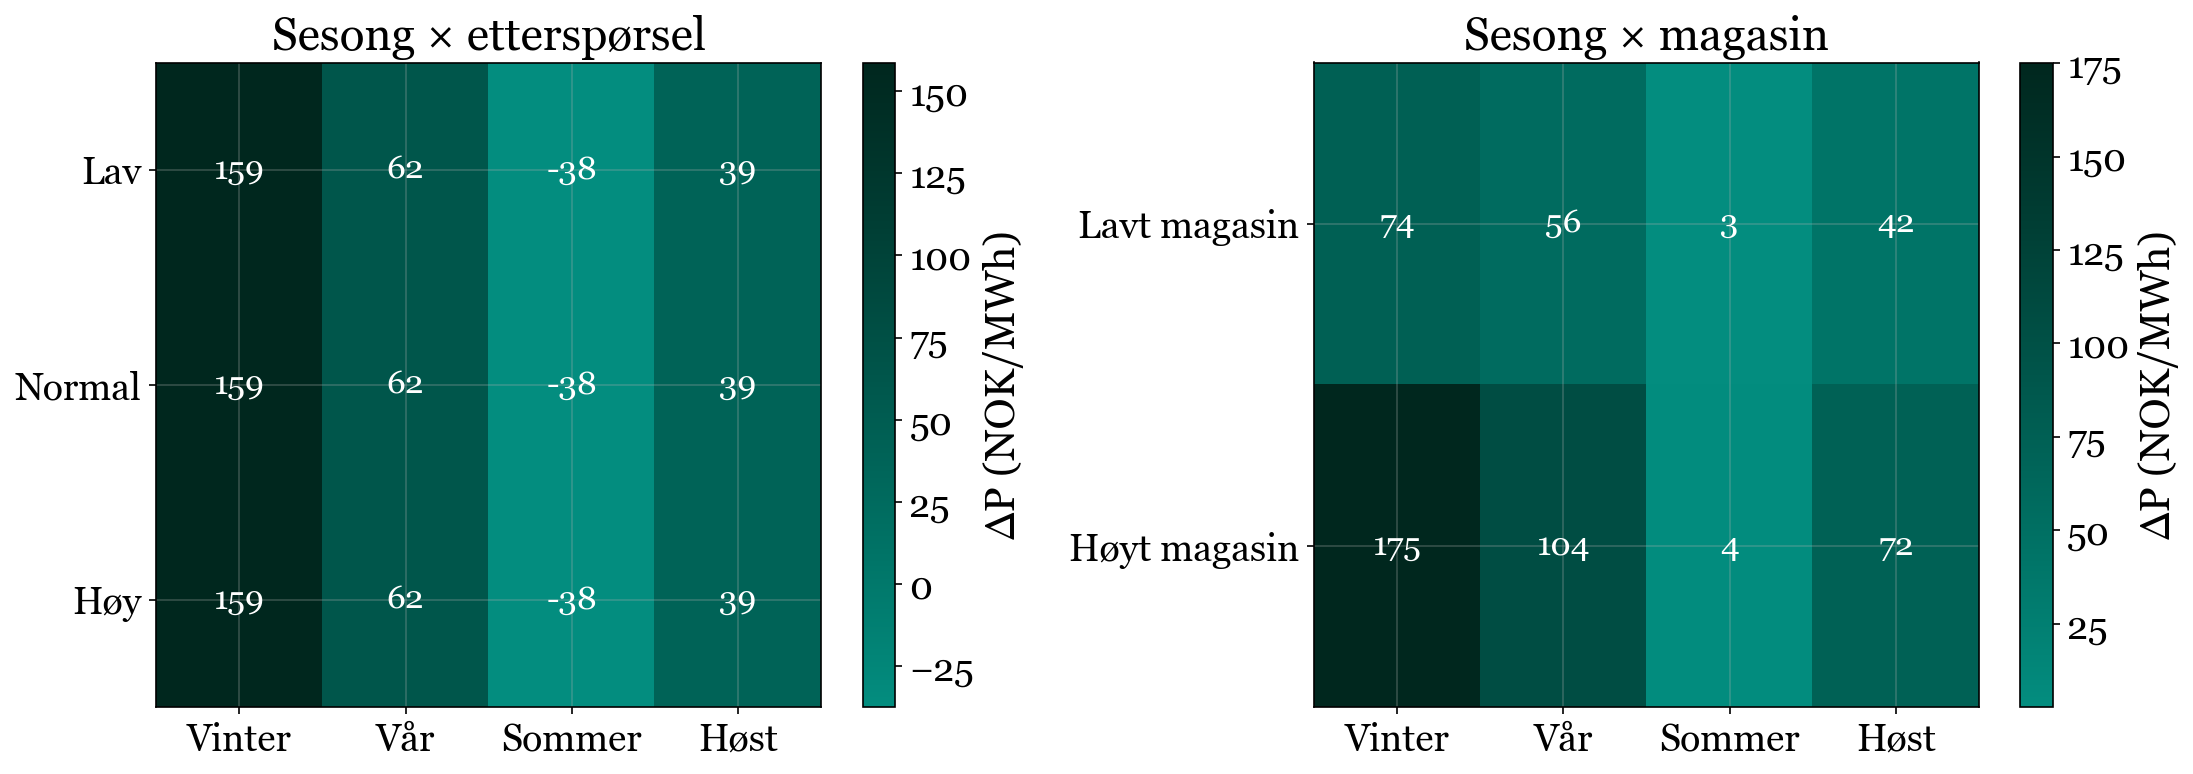

In [28]:
# Figur: heatmap sesong × etterspørsel og sesong × magasin
from matplotlib.colors import LinearSegmentedColormap

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
heat_cmap = LinearSegmentedColormap.from_list("thesis_green", PALETTE)

for ax, df_h, ttl in [
    (axes[0], tab,  "Sesong × etterspørsel"),
    (axes[1], tab2, "Sesong × magasin"),
]:
    values = df_h.values.astype(float)
    vmin = np.nanmin(values)
    vmax = np.nanmax(values)
    im = ax.imshow(values, cmap=heat_cmap, aspect="auto", vmin=vmin, vmax=vmax)

    ax.set_xticks(range(len(df_h.columns)))
    ax.set_xticklabels(df_h.columns)
    ax.set_yticks(range(len(df_h.index)))
    ax.set_yticklabels(df_h.index)

    threshold = vmin + 0.55 * (vmax - vmin)
    for i in range(df_h.shape[0]):
        for j in range(df_h.shape[1]):
            v = values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                        fontsize=16,
                        color="white")

    ax.set_title(ttl)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("ΔP (NOK/MWh)")

plt.tight_layout()
plt.savefig(FIG6 + "78_heatmap_naar_storst.pdf", bbox_inches="tight")
plt.show()


---
# 7.9 Robusthet og skaleringsscenario: 230 vs 520 MW (delspørsmål 4.2)

Hovedanalysen rapporterer +230 MW som planlagt første fase. Her brukes +520 MW som et større skaleringsscenario: dels for å teste om modellene skalerer omtrent lineært, dels for å vise samlet priseffekt dersom fase 1 og 2 realiseres.


In [29]:
# Tabell: ΔP 230 vs 520, ratio (test for linearitet — forventet 520/230 ≈ 2.26)
expected_ratio = STARGATE_TOTAL_MW / STARGATE_MW
rows = []
for name, col in MODEL_DP.items():
    dp230 = scenarios[STARGATE_MW][col].mean()
    dp520 = scenarios[STARGATE_TOTAL_MW][col].mean()
    rows.append({
        "Modell":           name,
        "ΔP +230 MW":       round(dp230, 1),
        "ΔP +520 MW":       round(dp520, 1),
        "Ratio (520/230)":  round(dp520 / dp230, 2) if dp230 != 0 else np.nan,
        "Forventet (lineær)": round(expected_ratio, 2),
    })
robust_dp_df = pd.DataFrame(rows).set_index("Modell")
print("Tabell 7.16: Robusthet og skaleringsscenario — 230 vs 520 MW per modell")
display(robust_dp_df)

# Kort samlet +520-oppsummering med hovedmodellen (2SLS)
pr_base = iso_share_df.loc["Baseline", "Total"] / 100
pr_230 = iso_share_df.loc["+230 MW", "Total"] / 100
pr_520 = iso_share_df.loc["+520 MW", "Total"] / 100
summary_520 = pd.DataFrame([
    {
        "Scenario": "+230 MW",
        "ΔP|ISO 2SLS": round(scenarios[STARGATE_MW]["dP_TSLS"].mean(), 1),
        "Predikert ISO-andel (%)": round(pr_230 * 100, 1),
        "ΔPr(ISO) (pp)": round((pr_230 - pr_base) * 100, 2),
        "Total ΔE[P] 2SLS": round(
            pr_base * scenarios[STARGATE_MW]["dP_TSLS"].mean()
            + (pr_230 - pr_base) * dp_gap_total, 1
        ),
    },
    {
        "Scenario": "+520 MW",
        "ΔP|ISO 2SLS": round(scenarios[STARGATE_TOTAL_MW]["dP_TSLS"].mean(), 1),
        "Predikert ISO-andel (%)": round(pr_520 * 100, 1),
        "ΔPr(ISO) (pp)": round((pr_520 - pr_base) * 100, 2),
        "Total ΔE[P] 2SLS": round(
            pr_base * scenarios[STARGATE_TOTAL_MW]["dP_TSLS"].mean()
            + (pr_520 - pr_base) * dp_gap_total, 1
        ),
    },
]).set_index("Scenario")
print("\nTabell 7.17: Samlet 2SLS-effekt for +230 og +520 MW")
display(summary_520.style.format("{:.1f}"))


Tabell 7.16: Robusthet og skaleringsscenario — 230 vs 520 MW per modell


,ΔP +230 MW,ΔP +520 MW,Ratio (520/230),Forventet (lineær)
Modell,,,,
2SLS (HAC),141.700000,320.500000,2.26,2.26
OLS (HAC),69.800000,157.800000,2.26,2.26
QuantReg Q50,25.600000,57.800000,2.26,2.26
QuantReg Q90,50.900000,115.100000,2.26,2.26
OLS (sesong),58.000000,131.100000,2.26,2.26
XGBoost,64.400002,137.199997,2.13,2.26
MS-DR,62.600000,141.600000,2.26,2.26



Tabell 7.17: Samlet 2SLS-effekt for +230 og +520 MW


,ΔP|ISO 2SLS,Predikert ISO-andel (%),ΔPr(ISO) (pp),Total ΔE[P] 2SLS
Scenario,,,,
+230 MW,141.7,76.0,3.5,105.4
+520 MW,320.5,80.0,7.5,238.0


I tillegg til modellratio rapporteres +520 MW etter sesong og etterspørselsnivå. Dette skiller mellom direkte priseffekt i ISO-timer og total forventet prisvirkning når endret ISO-sannsynlighet også tas med.


In [30]:
# Skaleringsscenario +520 MW: variasjon etter sesong og etterspørselsnivå
res520 = scenarios[STARGATE_TOTAL_MW]
hetero_models = {
    "OLS (sesong)": MODEL_DP["OLS (sesong)"],
    "XGBoost": MODEL_DP["XGBoost"],
}

# Direkte ΔP-heterogenitet i modeller som varierer over observasjoner
season_520_rows = []
for name, col in hetero_models.items():
    row = {"Modell": name, "Total": round(res520[col].mean(), 1)}
    for s_en, s_no in SEASON_ORDER.items():
        row[s_no] = round(res520.loc[res520["season"] == s_en, col].mean(), 1)
    season_520_rows.append(row)
season_520_df = pd.DataFrame(season_520_rows).set_index("Modell")
print("Tabell 7.18: Direkte ΔP i skaleringsscenarioet (+520 MW) per sesong")
display(season_520_df.style.format("{:.1f}"))

demand_520_rows = []
for lvl in DEMAND_LEVELS:
    mask = res520["demand_level"] == lvl
    row = {"Etterspørsel": lvl}
    for name, col in hetero_models.items():
        row[name] = round(res520.loc[mask, col].mean(), 1)
    demand_520_rows.append(row)
demand_520_df = pd.DataFrame(demand_520_rows).set_index("Etterspørsel")
print("\nTabell 7.19: Direkte ΔP i skaleringsscenarioet (+520 MW) per etterspørselsnivå")
display(demand_520_df.style.format("{:.1f}"))

# Total 2SLS/Roy-effekt: variasjon kommer fra ISO-andel og prisgap, ikke fra 2SLS-betaen.
dp_gap_season_520 = {}
for s_en in SEASON_ORDER:
    m = df["season"] == s_en
    dp_gap_season_520[s_en] = (
        df.loc[m & (df["is_iso"] == 1), TARGET].mean()
        - df.loc[m & (df["is_iso"] == 0), TARGET].mean()
    )

dp_gap_demand_520 = {}
for lvl in DEMAND_LEVELS:
    m = df["demand_level_all"] == lvl
    dp_gap_demand_520[lvl] = (
        df.loc[m & (df["is_iso"] == 1), TARGET].mean()
        - df.loc[m & (df["is_iso"] == 0), TARGET].mean()
    )

dp_tsls_520 = res520["dP_TSLS"].mean()
season_total_520_rows = []
for s_en, s_no in SEASON_ORDER.items():
    pr_base_s = iso_share_df.loc["Baseline", s_no] / 100
    pr_520_s = iso_share_df.loc["+520 MW", s_no] / 100
    d_pr_s = pr_520_s - pr_base_s
    gap_s = dp_gap_season_520[s_en]
    t1_s = pr_base_s * dp_tsls_520
    t2_s = d_pr_s * gap_s
    season_total_520_rows.append({
        "Sesong": s_no,
        "Pr(ISO) baseline (%)": round(pr_base_s * 100, 1),
        "Pr(ISO) +520 (%)": round(pr_520_s * 100, 1),
        "ΔPr(ISO) (pp)": round(d_pr_s * 100, 2),
        "Term 1": round(t1_s, 1),
        "Term 2": round(t2_s, 1),
        "Total ΔE[P]": round(t1_s + t2_s, 1),
    })
season_total_520_df = pd.DataFrame(season_total_520_rows).set_index("Sesong")
print("\nTabell 7.20: Total 2SLS-effekt i skaleringsscenarioet (+520 MW) per sesong")
display(season_total_520_df.style.format("{:.1f}"))

demand_total_520_rows = []
for lvl in DEMAND_LEVELS:
    pr_base_d = iso_demand_df.loc["Baseline", lvl] / 100
    pr_520_d = iso_demand_df.loc["+520 MW", lvl] / 100
    d_pr_d = pr_520_d - pr_base_d
    gap_d = dp_gap_demand_520[lvl]
    t1_d = pr_base_d * dp_tsls_520
    t2_d = d_pr_d * gap_d
    demand_total_520_rows.append({
        "Etterspørsel": lvl,
        "Pr(ISO) baseline (%)": round(pr_base_d * 100, 1),
        "Pr(ISO) +520 (%)": round(pr_520_d * 100, 1),
        "ΔPr(ISO) (pp)": round(d_pr_d * 100, 2),
        "Term 1": round(t1_d, 1),
        "Term 2": round(t2_d, 1),
        "Total ΔE[P]": round(t1_d + t2_d, 1),
    })
demand_total_520_df = pd.DataFrame(demand_total_520_rows).set_index("Etterspørsel")
print("\nTabell 7.21: Total 2SLS-effekt i skaleringsscenarioet (+520 MW) per etterspørselsnivå")
display(demand_total_520_df.style.format("{:.1f}"))


Tabell 7.18: Direkte ΔP i skaleringsscenarioet (+520 MW) per sesong


,Total,Vinter,Vår,Sommer,Høst
Modell,,,,,
OLS (sesong),131.1,358.8,139.0,-84.9,88.2
XGBoost,137.2,196.5,153.5,29.6,166.1



Tabell 7.19: Direkte ΔP i skaleringsscenarioet (+520 MW) per etterspørselsnivå


,OLS (sesong),XGBoost
Etterspørsel,,
Lav,-25.0,19.1
Normal,118.2,210.7
Høy,267.6,169.3



Tabell 7.20: Total 2SLS-effekt i skaleringsscenarioet (+520 MW) per sesong


,Pr(ISO) baseline (%),Pr(ISO) +520 (%),ΔPr(ISO) (pp),Term 1,Term 2,Total ΔE[P]
Sesong,,,,,,
Vinter,76.0,82.7,6.7,243.6,5.4,249.0
Vår,67.6,75.9,8.3,216.6,5.2,221.9
Sommer,75.5,82.4,6.9,242.0,3.7,245.7
Høst,70.8,79.0,8.2,226.9,6.5,233.4



Tabell 7.21: Total 2SLS-effekt i skaleringsscenarioet (+520 MW) per etterspørselsnivå


,Pr(ISO) baseline (%),Pr(ISO) +520 (%),ΔPr(ISO) (pp),Term 1,Term 2,Total ΔE[P]
Etterspørsel,,,,,,
Lav,71.1,78.8,7.7,227.9,6.2,234.1
Normal,69.8,77.9,8.1,223.7,5.8,229.5
Høy,76.4,83.2,6.8,244.8,2.2,247.0


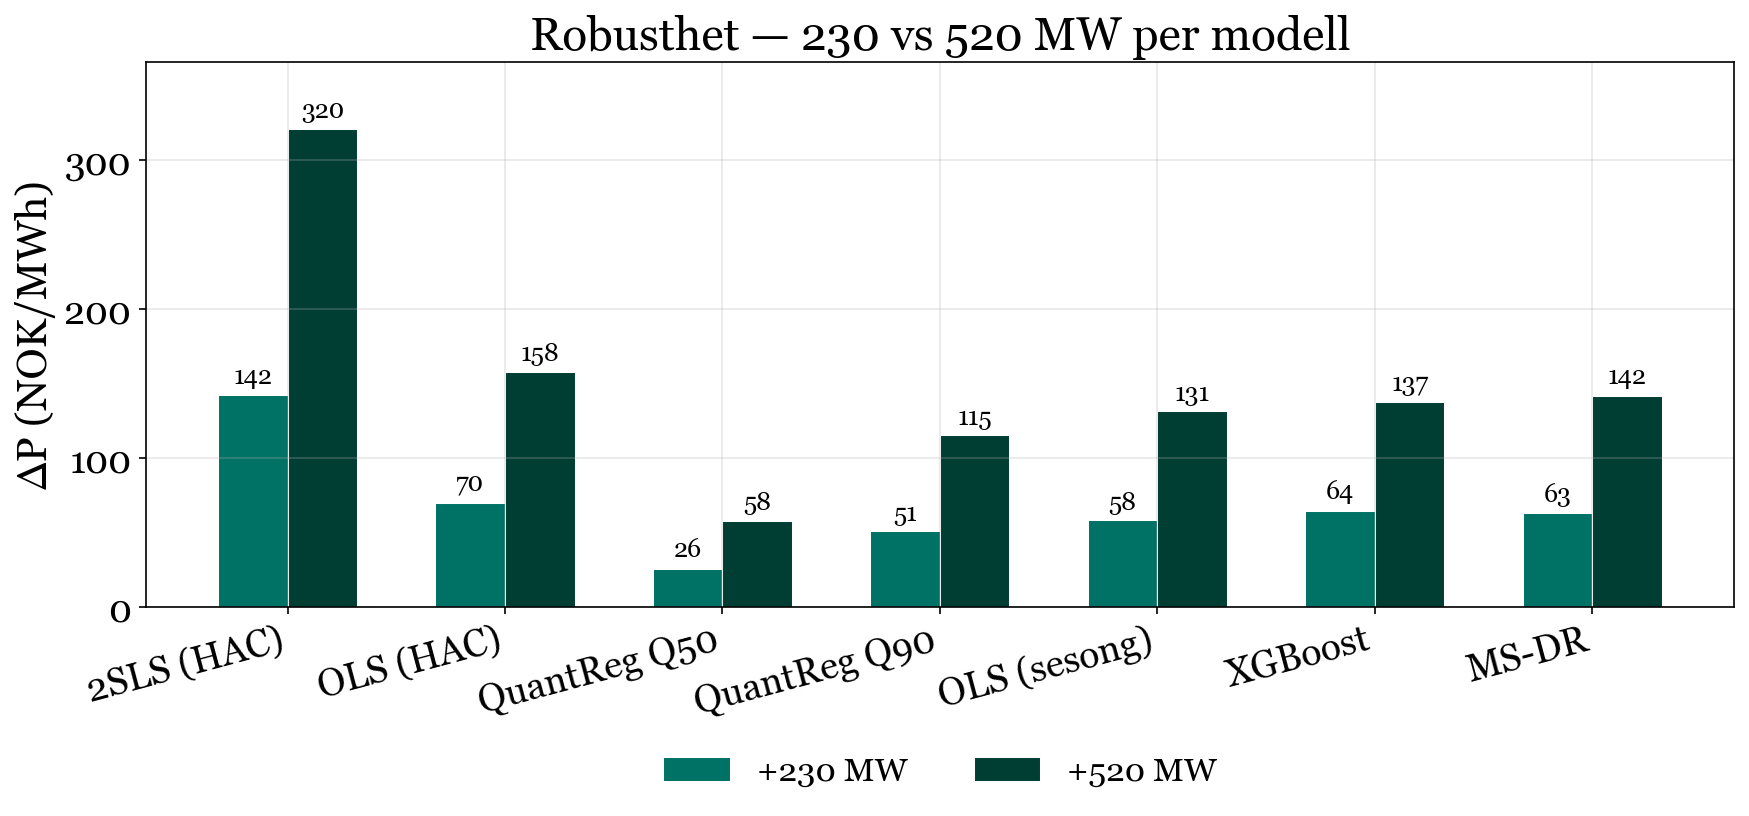

In [31]:
# Figur: ΔP 230 vs 520 — gruppert søylediagram
model_names = list(MODEL_DP.keys())
x = np.arange(len(model_names))
width = 0.32

fig, ax = plt.subplots(figsize=(12, 6))
vals_230 = [scenarios[STARGATE_MW][col].mean()       for col in MODEL_DP.values()]
vals_520 = [scenarios[STARGATE_TOTAL_MW][col].mean() for col in MODEL_DP.values()]

bars_230 = ax.bar(x - width/2, vals_230, width, color=C2, label="+230 MW",
                  edgecolor="white", linewidth=0.5)
bars_520 = ax.bar(x + width/2, vals_520, width, color=C4, label="+520 MW",
                  edgecolor="white", linewidth=0.5)

for bars, vals in [(bars_230, vals_230), (bars_520, vals_520)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals_520) * 0.012,
                f"{v:.0f}", ha="center", va="bottom", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylabel("ΔP (NOK/MWh)")
ax.set_title("Robusthet — 230 vs 520 MW per modell")
ax.set_ylim(top=max(vals_520) * 1.14)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels,
          ncol=2, frameon=False,
          bbox_to_anchor=(0.5, -0.22), loc="upper center")

plt.tight_layout()
plt.savefig(FIG6 + "79_230_vs_520.pdf", bbox_inches="tight")
plt.show()


---
# 7.10 Oppsummering — total priseffekt dekomponert (Roy)

$$\Delta E[P] \;\approx\; \underbrace{\Pr(I=1)\cdot\Delta E[P\mid I=1]}_{\text{Term 1: direkte}} \;+\; \underbrace{\Delta\Pr(I=1)\cdot\Delta P_{\text{gap}}}_{\text{Term 2: regimeskift}}$$

- $\Pr(I=1)$: faktisk ISO-andel
- $\Delta E[P\mid I=1]$: estimert prisøkning per modell i ISO-timer
- $\Delta\Pr(I=1)$: økning i ISO-andel fra logit (Stargate-scenario)
- $\Delta P_{\text{gap}}$: historisk prisgap (snitt ISO − snitt pristaker)

In [32]:
# Sesong-spesifikt prisgap
dp_gap_season = {}
for s_en in SEASON_ORDER:
    m = df["season"] == s_en
    dp_gap_season[s_en] = (df.loc[m & (df["is_iso"] == 1), "price_NO4"].mean()
                          - df.loc[m & (df["is_iso"] == 0), "price_NO4"].mean())

# Etterspørsels-spesifikt prisgap
dp_gap_demand = {}
for lvl in DEMAND_LEVELS:
    m = df["demand_level_all"] == lvl
    dp_gap_demand[lvl] = (df.loc[m & (df["is_iso"] == 1), "price_NO4"].mean()
                         - df.loc[m & (df["is_iso"] == 0), "price_NO4"].mean())

print("Historisk prisgap (ISO − pristaker), NOK/MWh:")
print(f"  Totalt:     {dp_gap_total:+.1f}")
for s_en, gap in dp_gap_season.items():
    print(f"  {SEASON_ORDER[s_en]:8s}  {gap:+.1f}")
for lvl, gap in dp_gap_demand.items():
    print(f"  {lvl:8s}  {gap:+.1f}")

Historisk prisgap (ISO − pristaker), NOK/MWh:
  Totalt:     +75.4
  Vinter    +81.3
  Vår       +63.2
  Sommer    +54.3
  Høst      +78.9
  Lav       +80.8
  Normal    +71.6
  Høy       +32.3


In [33]:
# Total dekomponert effekt — alle modeller, +230 MW
total_rows = []
delta, lbl = STARGATE_MW, "+230 MW"
res     = scenarios[delta]
pr_base = iso_share_df.loc["Baseline", "Total"] / 100
pr_scen = iso_share_df.loc[lbl,        "Total"] / 100
d_pr    = pr_scen - pr_base
for name, col in MODEL_DP.items():
    dP_iso = res[col].mean()
    t1 = pr_base * dP_iso
    t2 = d_pr    * dp_gap_total
    total_rows.append({
        "Scenario":              lbl,
        "Modell":                name,
        "Pr(ISO) (%)":           round(pr_base * 100, 1),
        "ΔPr(ISO) (pp)":         round(d_pr    * 100, 2),
        "ΔP|ISO":                round(dP_iso, 1),
        "ΔP_gap":                round(dp_gap_total, 1),
        "Term 1 (direkte)":      round(t1, 1),
        "Term 2 (regimeskift)":  round(t2, 1),
        "Total ΔE[P]":           round(t1 + t2, 1),
    })
df_total = pd.DataFrame(total_rows)
print("Tabell 7.22: Total priseffekt dekomponert (Roy-formelen) — alle modeller, +230 MW")
display(df_total)


Tabell 7.22: Total priseffekt dekomponert (Roy-formelen) — alle modeller, +230 MW


,Scenario,Modell,Pr(ISO) (%),ΔPr(ISO) (pp),ΔP|ISO,ΔP_gap,Term 1 (direkte),Term 2 (regimeskift),Total ΔE[P]
0,+230 MW,2SLS (HAC),72.5,3.5,141.700000,75.4,102.8,2.6,105.4
1,+230 MW,OLS (HAC),72.5,3.5,69.800000,75.4,50.6,2.6,53.2
2,+230 MW,QuantReg Q50,72.5,3.5,25.600000,75.4,18.5,2.6,21.2
3,+230 MW,QuantReg Q90,72.5,3.5,50.900000,75.4,36.9,2.6,39.5
4,+230 MW,OLS (sesong),72.5,3.5,58.000000,75.4,42.0,2.6,44.7
5,+230 MW,XGBoost,72.5,3.5,64.400002,75.4,46.7,2.6,49.4
6,+230 MW,MS-DR,72.5,3.5,62.600000,75.4,45.4,2.6,48.0


In [34]:
# Per sesong (2SLS HAC, +230 MW)
season_rows = []
res = scenarios[STARGATE_MW]
for s_en, s_no in SEASON_ORDER.items():
    pr_base_s = iso_share_df.loc["Baseline", s_no] / 100
    pr_scen_s = iso_share_df.loc["+230 MW", s_no] / 100
    d_pr_s    = pr_scen_s - pr_base_s
    gap_s     = dp_gap_season[s_en]
    m         = res["season"] == s_en
    dP_iso_s  = res.loc[m, "dP_TSLS"].mean()
    t1_s = pr_base_s * dP_iso_s
    t2_s = d_pr_s    * gap_s
    season_rows.append({
        "Scenario": "+230 MW", "Sesong": s_no,
        "Pr(ISO) (%)":     round(pr_base_s * 100, 1),
        "ΔPr(ISO) (pp)":   round(d_pr_s * 100, 2),
        "ΔP|ISO":          round(dP_iso_s, 1),
        "ΔP_gap":          round(gap_s, 1),
        "Term 1":           round(t1_s, 1),
        "Term 2":           round(t2_s, 1),
        "Total ΔE[P]":     round(t1_s + t2_s, 1),
    })
df_season_total = pd.DataFrame(season_rows)
print("Tabell 7.23: Total priseffekt dekomponert per sesong (2SLS HAC, +230 MW)")
display(df_season_total)


Tabell 7.23: Total priseffekt dekomponert per sesong (2SLS HAC, +230 MW)


,Scenario,Sesong,Pr(ISO) (%),ΔPr(ISO) (pp),ΔP|ISO,ΔP_gap,Term 1,Term 2,Total ΔE[P]
0,+230 MW,Vinter,76.0,3.1,141.7,81.3,107.7,2.5,110.2
1,+230 MW,Vår,67.6,3.8,141.7,63.2,95.8,2.4,98.2
2,+230 MW,Sommer,75.5,3.2,141.7,54.3,107.0,1.7,108.8
3,+230 MW,Høst,70.8,3.9,141.7,78.9,100.4,3.1,103.4


In [35]:
# Per etterspørselsnivå (2SLS HAC, +230 MW)
demand_rows = []
res = scenarios[STARGATE_MW]
for lvl in DEMAND_LEVELS:
    pr_base_d = iso_demand_df.loc["Baseline", lvl] / 100
    pr_scen_d = iso_demand_df.loc["+230 MW", lvl] / 100
    d_pr_d    = pr_scen_d - pr_base_d
    gap_d     = dp_gap_demand[lvl]
    m         = res["demand_level"] == lvl
    dP_iso_d  = res.loc[m, "dP_TSLS"].mean()
    t1_d = pr_base_d * dP_iso_d
    t2_d = d_pr_d    * gap_d
    demand_rows.append({
        "Scenario": "+230 MW", "Etterspørsel": lvl,
        "Pr(ISO) (%)":     round(pr_base_d * 100, 1),
        "ΔPr(ISO) (pp)":   round(d_pr_d * 100, 2),
        "ΔP|ISO":          round(dP_iso_d, 1),
        "ΔP_gap":          round(gap_d, 1),
        "Term 1":           round(t1_d, 1),
        "Term 2":           round(t2_d, 1),
        "Total ΔE[P]":     round(t1_d + t2_d, 1),
    })
df_demand_total = pd.DataFrame(demand_rows)
print("Tabell 7.24: Total priseffekt dekomponert per etterspørselsnivå (2SLS HAC, +230 MW)")
display(df_demand_total)


Tabell 7.24: Total priseffekt dekomponert per etterspørselsnivå (2SLS HAC, +230 MW)


,Scenario,Etterspørsel,Pr(ISO) (%),ΔPr(ISO) (pp),ΔP|ISO,ΔP_gap,Term 1,Term 2,Total ΔE[P]
0,+230 MW,Lav,71.1,3.6,141.7,80.8,100.8,2.9,103.7
1,+230 MW,Normal,69.8,3.8,141.7,71.6,98.9,2.7,101.7
2,+230 MW,Høy,76.4,3.2,141.7,32.3,108.3,1.0,109.3


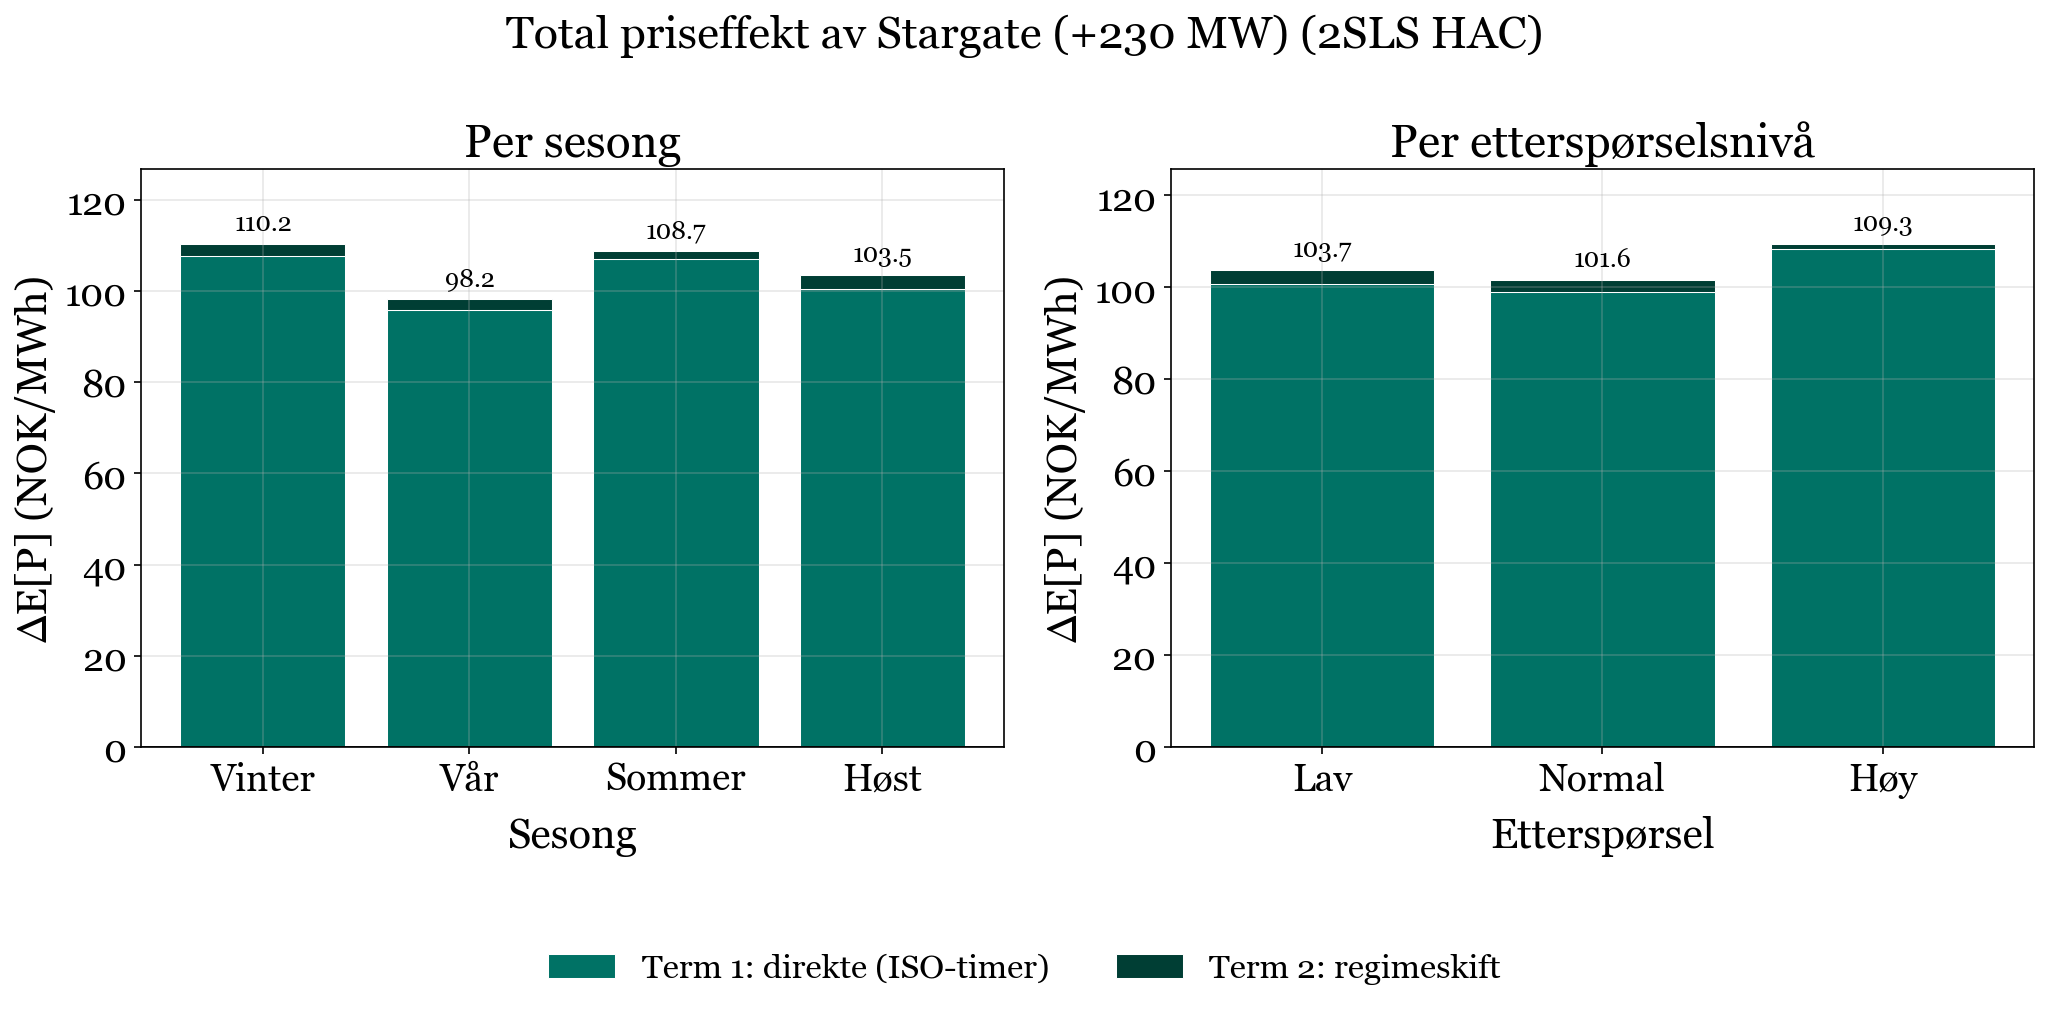

In [36]:
# Figur: stacked bar — Term 1 + Term 2 per sesong og per etterspørselsnivå (+230 MW, 2SLS HAC)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df_strat, strat_col, title in [
    (axes[0], df_season_total[df_season_total["Scenario"] == "+230 MW"], "Sesong",       "Per sesong"),
    (axes[1], df_demand_total[df_demand_total["Scenario"] == "+230 MW"], "Etterspørsel", "Per etterspørselsnivå"),
]:
    cats = df_strat[strat_col].tolist()
    t1_v = df_strat["Term 1"].values
    t2_v = df_strat["Term 2"].values
    total_v = t1_v + t2_v
    x = np.arange(len(cats))

    ax.bar(x, t1_v, color=C2, label="Term 1: direkte (ISO-timer)",
           edgecolor="white", linewidth=0.5)
    ax.bar(x, t2_v, bottom=t1_v, color=C4, label="Term 2: regimeskift",
           edgecolor="white", linewidth=0.5)
    for xi, tv in zip(x, total_v):
        ax.text(xi, tv + max(total_v) * 0.015, f"{tv:.1f}",
                ha="center", va="bottom", fontsize=12)

    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(cats)
    ax.set_xlabel(strat_col, labelpad=8)
    ax.set_ylabel("ΔE[P] (NOK/MWh)")
    ax.set_title(title)
    ax.set_ylim(top=max(total_v) * 1.15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.03), loc="upper center")
fig.suptitle("Total priseffekt av Stargate (+230 MW) (2SLS HAC)")
plt.tight_layout()
plt.savefig(FIG6 + "710_total_priseffekt_dekomponert.pdf", bbox_inches="tight")
plt.show()


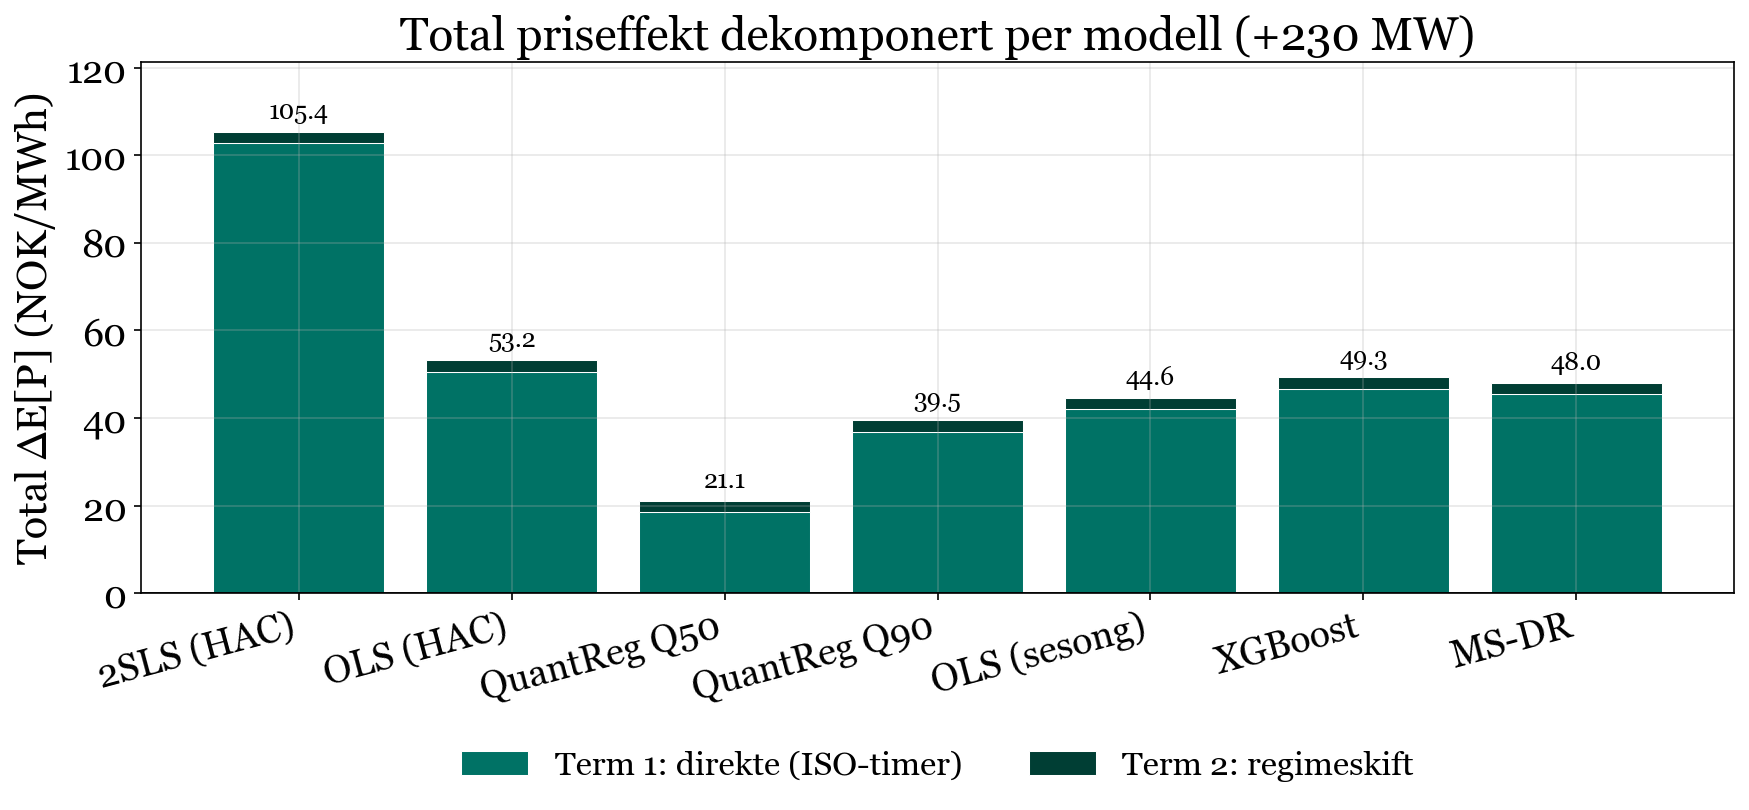

Notebook 06 ferdig. Alle figurer lagret i ../figures/notebook/06/


In [37]:
# Figur: dekomponering per modell (+230 MW)
df230 = df_total[df_total["Scenario"] == "+230 MW"].set_index("Modell")
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df230))
t1_v = df230["Term 1 (direkte)"].values
t2_v = df230["Term 2 (regimeskift)"].values
total_v = t1_v + t2_v

ax.bar(x, t1_v, color=C2, label="Term 1: direkte (ISO-timer)",
       edgecolor="white", linewidth=0.5)
ax.bar(x, t2_v, bottom=t1_v, color=C4, label="Term 2: regimeskift",
       edgecolor="white", linewidth=0.5)
for xi, tv in zip(x, total_v):
    ax.text(xi, tv + max(total_v) * 0.015, f"{tv:.1f}",
            ha="center", va="bottom", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(df230.index, rotation=15, ha="right")
ax.set_ylabel("Total ΔE[P] (NOK/MWh)")
ax.set_title("Total priseffekt dekomponert per modell (+230 MW)")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylim(top=max(total_v) * 1.15)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels,
          ncol=2, frameon=False,
          bbox_to_anchor=(0.5, -0.24), loc="upper center")

plt.tight_layout()
plt.savefig(FIG6 + "711_dekomponert_per_modell.pdf", bbox_inches="tight")
plt.show()

print("Notebook 06 ferdig. Alle figurer lagret i", FIG6)
